## Credit Card Fraud Detection

In this project you will predict fraudulent credit card transactions with the help of Machine learning models. Please import the following libraries to get started.

## Detailed implementation plan (updated for training-time optimizations)

### Objective
An end-to-end credit card fraud detection notebook will be produced from the provided starter notebook by filling every placeholder cell in place

- Training on **raw (imbalanced)** data
- Training on **balanced** data using **Random Oversampling**, **SMOTE**, and **ADASYN** (test set untouched)
- Model selection using **ROC-AUC** with **top-3** deep dives (ROC-threshold + full metrics)
- A **cost-based operating strategy** evaluated across a **C_alert grid**, plus final imbalanced vs balanced comparison artifacts
- **Training-time optimizations** applied without changing the notebook structure or evaluation logic:
  - **Outer + Inner parallelism**
  - **Multi-metric scoring** (ROC-AUC + PR-AUC) without an extra CV pass
  - **Pipeline caching**
  - **GPU XGBoost** (`device="cuda"`)

---

### Model list (used in the imbalanced track; balanced track excludes SMOTE+RandomForest)
The following model families will be trained, tuned, and ranked consistently:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Support Vector Machine (SVM)**
   - Probability outputs enabled (for ROC curves, thresholding, and cost optimization).
   - Tuning ranges bounded for stability/runtime.
4. **Decision Tree**
5. **Random Forest**
6. **Gradient Boosted Trees (GBM)**
   - Fast boosted-tree baseline suitable for tabular data.
7. **XGBoost (GPU-enabled)**
   - High-capacity boosted model with regularization and efficient split search.

All models are tuned with randomized hyperparameter search and evaluated under stratified k-fold cross-validation.

---

### Parallel training requirement (outer + Inner parallelism)
To reduce training time without compromising evaluation quality, parallelism is implemented:

- **Outer parallelism:** model (or sampler+model) search jobs executed concurrently via joblib `Parallel` with `OUTER_NJOBS` (e.g., 4–8 depending on CPU).
- **Inner parallelism:** enabled (`RandomizedSearchCV(n_jobs=-1)`).
- **Estimator-level parallelism:** enabled (`n_jobs=-1` for estimators that support it).

---

### Phase 1 — Data loading, EDA, feature decisions (starter section)
1. **Load data** (`creditcard.csv`) with a Colab-safe fallback download if the file is absent.
2. **Dataset inspection**: schema, missing values, duplicates, summary statistics.
3. **Class distribution**: counts and percentages + bar plot.
4. **EDA visuals**: class behavior over Time and Amount (scatter / distribution plots; sampled where needed).
5. **Feature engineering + dropping columns**:
   - Derive time-based features from `Time` (e.g., hour-of-day + cyclical encodings).
   - Create `log1p_amount` for modeling.
   - Drop raw `Time` from modeling features after derivation.
   - Preserve raw `Amount` separately for cost computation.

---

### Phase 2 — Train/test split + skewness mitigation (starter section)
1. **Stratified train/test split** (e.g., 80/20) with fixed random seed.
2. **Skewness check** on training features.
3. **Skewness mitigation** using `PowerTransformer` (fit on train only, transform train and test).
4. **Before/after distribution plots** for selected skewed variables (required evidence).

---

### Phase 3 — Model building on raw (imbalanced) data
1. **Cross-validation**: StratifiedKFold with a k that preserves minority presence per fold.
2. **Hyperparameter tuning**: RandomizedSearchCV (primary score: ROC-AUC).
3. **Leaderboard**: mean CV **ROC-AUC (primary)** and **PR-AUC (supporting)** using **multi-metric scoring** in the *same* CV run (no extra CV pass).
4. **Top-3 selection** by mean CV ROC-AUC.
5. **Top-3 thresholding requirement**:
   - Out-of-fold probabilities on training.
   - ROC curve computed from OOF predictions.
   - ROC threshold selected using Youden’s J (`argmax(tpr - fpr)`).
   - Metrics at the chosen threshold: confusion matrix, precision, recall, F1, accuracy (train OOF + test).

Deliverables in this phase:
- Top-3 imbalanced models + thresholds + metric tables
- Best imbalanced model identifier used in later cost sensitivity evaluation

---

### Phase 4 — Model building with balancing (Random Oversampling, SMOTE, ADASYN)
1. **Test set remains unchanged** throughout.
2. Balanced training executed using samplers applied to training only:
   - Random Oversampling
   - SMOTE
   - ADASYN
3. Leakage-safe approach:
   - Resampling occurs inside CV folds (sampler integrated into the training workflow).
4. For each sampler:
   - Train and tune the model list:
     - LogReg, KNN, SVM, Decision Tree, Random Forest, GBM, **XGBoost (GPU)**
   - Rank by CV ROC-AUC and select top 3.
   - Apply ROC-based thresholding and compute full metrics (train OOF + test).

Deliverables in this phase:
- Best balanced configuration selection: `best_bal_sampler + best_bal_model`

---



In [1]:
# ============================================================
# Environment setup + imports
# ============================================================

# Colab-friendly dependency installation
# -q keeps output compact; remove -q for verbose logs.
!pip -q install -U imbalanced-learn xgboost joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn import metrics
from sklearn import preprocessing

# Additional imports required for the full pipeline
import os
import time
import warnings
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

from joblib import Parallel, delayed
from IPython.display import display

import xgboost as xgb
from google.colab import drive
drive.mount("/content/drive")

PERSIST_ROOT = "/content/drive/MyDrive/fraud_persist"
PERSIST_IMB = f"{PERSIST_ROOT}/imbalanced"
PERSIST_BAL = f"{PERSIST_ROOT}/balanced"


warnings.filterwarnings("ignore")

# ============================================================
# Parallelism policy: OUTER + Inner (prevents oversubscription)
# ============================================================
RANDOM_STATE = 42

CPU_COUNT = os.cpu_count() or 1
print(f"CPU count: {CPU_COUNT}")
OUTER_NJOBS = -1
INNER_NJOBS = -1                  # IMPORTANT: enable inner parallelism
ESTIMATOR_NJOBS = -1              # IMPORTANT: enable estimator-level joblib parallelism


# Pipeline caching (not persistence)
from joblib import Memory

CACHE_DIR = "cache/pipeline_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
memory = Memory(location=CACHE_DIR, verbose=0)
print("Pipeline caching directory:", CACHE_DIR)

# Reproducible plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CPU count: 12
Pipeline caching directory: cache/pipeline_cache
Setup complete.


## Exploratory data analysis

We load the dataset and inspect the first few rows to confirm:
- the presence of `Time`, `Amount`, `V1..V28`
- the target label `Class` (1 = fraud, 0 = non-fraud)


In [2]:
# ============================================================
# Data loading (starter cell preserved; robust loading added)
# ============================================================

# The starter notebook expects a local 'creditcard.csv'.
# A fallback download is attempted when the file is not present.

DATA_PATH = "creditcard.csv"

FALLBACK_URLS = [
    # Public GitHub raw mirror (large file; may take some time)
    "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv",
]

def try_download_csv(path: str, urls: List[str]) -> None:
    """Attempt to download a CSV file from a list of URLs into `path`."""
    import urllib.request

    last_err = None
    for url in urls:
        try:
            print(f"Attempting download: {url}")
            urllib.request.urlretrieve(url, path)
            print(f"Download complete: {path}")
            return
        except Exception as e:
            last_err = e
            print(f"Download failed for: {url}\nReason: {e}\n")
    raise RuntimeError(
        "Dataset file not found and download attempts failed.\n"
        "Action required: upload 'creditcard.csv' to the Colab runtime (Files pane), "
        "then re-run this cell.\n"
        f"Last error: {last_err}"
    )

if not os.path.exists(DATA_PATH):
    try_download_csv(DATA_PATH, FALLBACK_URLS)

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# observe the different feature type present in the data

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values per column (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

print("\nDescribe (selected):")
display(df.describe(include="all").T.head(15))

# Schema validation (fail fast if structure is unexpected)
required_cols = {"Time", "Amount", "Class"}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Check PCA columns presence
v_cols = [c for c in df.columns if c.startswith("V")]
if len(v_cols) < 10:
    print("Warning: PCA component columns V1..V28 not detected as expected.")

print("\nClass distribution:")
display(df["Class"].value_counts().rename_axis("Class").to_frame("count"))

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null 

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0



Duplicate rows: 1081

Describe (selected):


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



Class distribution:


,count
Class,
0,284315
1,492


In [4]:
df.dropna(inplace=True)
print("\nMissing values per column after treatment (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

display(df.info())


Missing values per column after treatment (top 10):


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

### Class distribution

This dataset is highly imbalanced. We compute class counts and class percentages to quantify the imbalance.


In [5]:
classes=df['Class'].value_counts()
normal_share=classes[0]/df['Class'].count()*100
fraud_share=classes[1]/df['Class'].count()*100

summary = pd.DataFrame({
    "Class": [0, 1],
    "Count": [classes.get(0, 0), classes.get(1, 0)],
    "Share(%)": [normal_share, fraud_share]
})
display(summary)

print(f"Normal transactions share: {normal_share:.4f}%")
print(f"Fraudulent transactions share: {fraud_share:.4f}%")

,Class,Count,Share(%)
0,0,284315,99.827251
1,1,492,0.172749


Normal transactions share: 99.8273%
Fraudulent transactions share: 0.1727%


### Bar plot: non-fraud vs fraud (counts + percentages)

A bar plot makes the extreme imbalance visually obvious. We annotate counts and percentages on the bars.

A class distribution plot highlights the imbalance level and provides an immediate baseline for modeling decisions. The fraud class is expected to be extremely rare, making metrics such as ROC-AUC and PR-AUC more informative than accuracy alone.


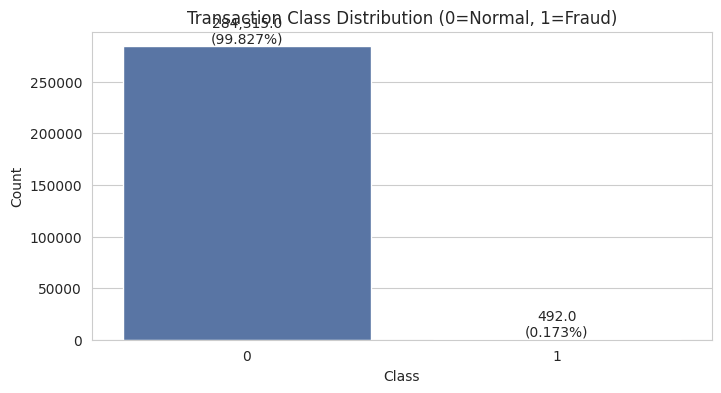

In [6]:
# Create a bar plot for the number and percentage of fraudulent vs non-fraudulent transcations

plt.figure(figsize=(8, 4))
ax = sns.countplot(x="Class", data=df, palette=["#4c72b0", "#dd8452"])
ax.set_title("Transaction Class Distribution (0=Normal, 1=Fraud)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

total = len(df)
for p in ax.patches:
    count = p.get_height()
    pct = 100.0 * count / total
    ax.annotate(f"{count:,}\n({pct:.3f}%)", (p.get_x() + p.get_width()/2., count),
                ha="center", va="bottom", fontsize=10)

plt.show()

## Exploratory Data Analysis (EDA): Time & Amount vs Fraud Class

This section visualizes how transactions differ between **fraud (Class = 1)** and **non-fraud (Class = 0)** across **Time** and **Amount**.

### What we will plot
1. **Scatter (sampled): Amount vs Time**  
   - Uses **stratified sampling** so the rare fraud class remains visible.
2. **Fraud rate by time bins**  
   - Aggregates transactions into time bins and plots the **mean fraud rate** per bin (with an optional smoothed trend).
3. **Amount distribution by class**  
   - Compares the distribution of `Amount` for each class using density histograms.
   - Also compares `log1p(Amount)` to reduce skew and visualize patterns more clearly.
4. **Boxplot (sampled): Amount by class**  
   - Provides a robust comparison of typical ranges and outliers between classes.

> Note: `Time` in the dataset is measured in **seconds elapsed**. For readability, we also create a derived feature `TimeHours = Time / 3600`.


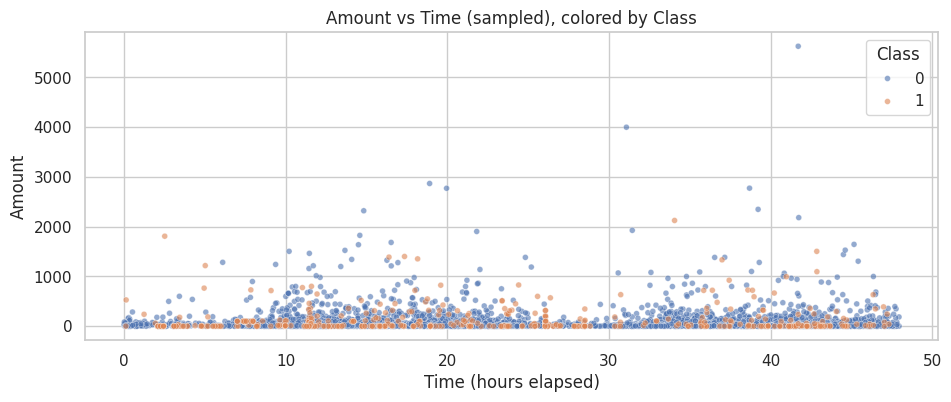

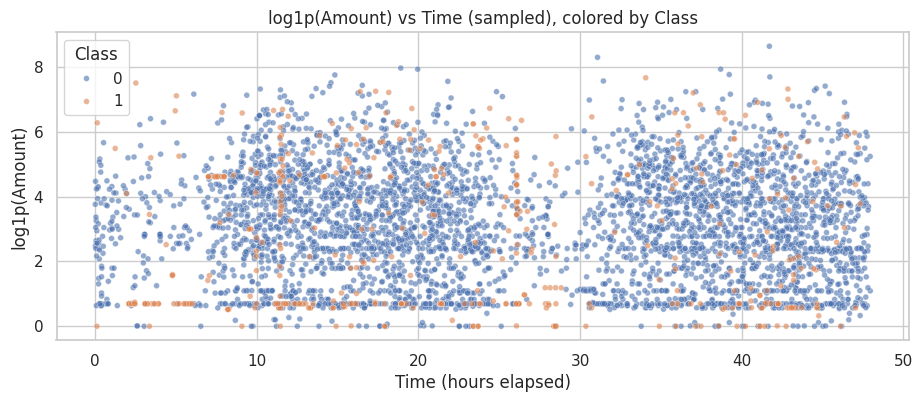

In [7]:
# Create a scatter plot to observe the distribution of classes with time
# --- Settings ---
sns.set(style="whitegrid")

# Add a readable time feature (hours)
df_plot = df.copy()
df_plot["Class"] = df_plot["Class"].astype(int)
PALETTE = {0: "#4c72b0", 1: "#dd8452"}  # non-fraud, fraud
df_plot["TimeHours"] = df_plot["Time"] / 3600.0

# ============================================================
# Scatter (sampled) - Amount vs Time (Hours), colored by class
# ============================================================

# Stratified sampling (cap each class to 4000)
n_per_class = 4000
plot_df = (
    df_plot.groupby("Class", group_keys=False)
    .apply(lambda x: x.sample(n=min(n_per_class, len(x)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

plt.figure(figsize=(11, 4))
sns.scatterplot(
    data=plot_df,
    x="TimeHours",
    y="Amount",
    hue="Class",
    alpha=0.6,
    s=18,
    palette=PALETTE
)
plt.title("Amount vs Time (sampled), colored by Class")
plt.xlabel("Time (hours elapsed)")
plt.ylabel("Amount")
plt.legend(title="Class")
plt.show()

# Optional: reduce outlier dominance for visibility
plt.figure(figsize=(11, 4))
sns.scatterplot(
    data=plot_df,
    x="TimeHours",
    y=np.log1p(plot_df["Amount"]),
    hue="Class",
    alpha=0.6,
    s=18,
    palette=PALETTE
)
plt.title("log1p(Amount) vs Time (sampled), colored by Class")
plt.xlabel("Time (hours elapsed)")
plt.ylabel("log1p(Amount)")
plt.legend(title="Class")
plt.show()

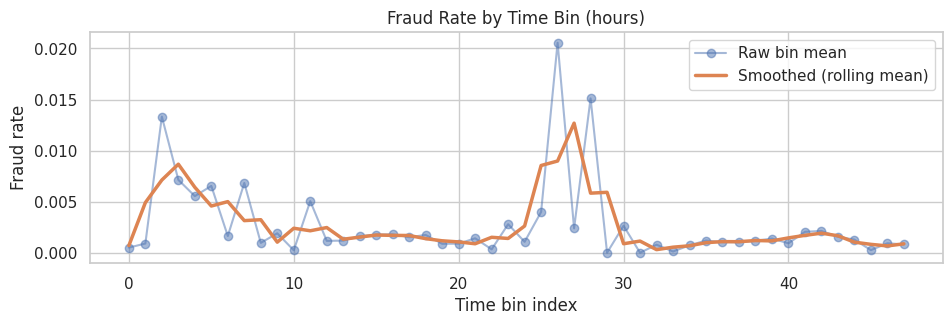

In [8]:
# ============================================================
# Fraud rate by time bins (more readable than raw scatter)
# ============================================================

bins = 48  # ~ hourly bins over 2 days
df_tmp = df_plot.copy()
df_tmp["time_bin"] = pd.cut(df_tmp["TimeHours"], bins=bins, include_lowest=True)

fraud_rate_by_bin = df_tmp.groupby("time_bin")["Class"].mean()

# Optional smoothing to make trend clearer
fraud_rate_smooth = fraud_rate_by_bin.rolling(window=3, center=True, min_periods=1).mean()

plt.figure(figsize=(11, 3))
plt.plot(fraud_rate_by_bin.values, marker="o", alpha=0.5, label="Raw bin mean")
plt.plot(fraud_rate_smooth.values, linewidth=2.5, label="Smoothed (rolling mean)")
plt.title("Fraud Rate by Time Bin (hours)")
plt.xlabel("Time bin index")
plt.ylabel("Fraud rate")
plt.legend()
plt.show()

An amount-based visualization clarifies whether fraud exhibits different transaction size patterns. Log scaling helps reveal behavior in the heavy right tail of the amount distribution.


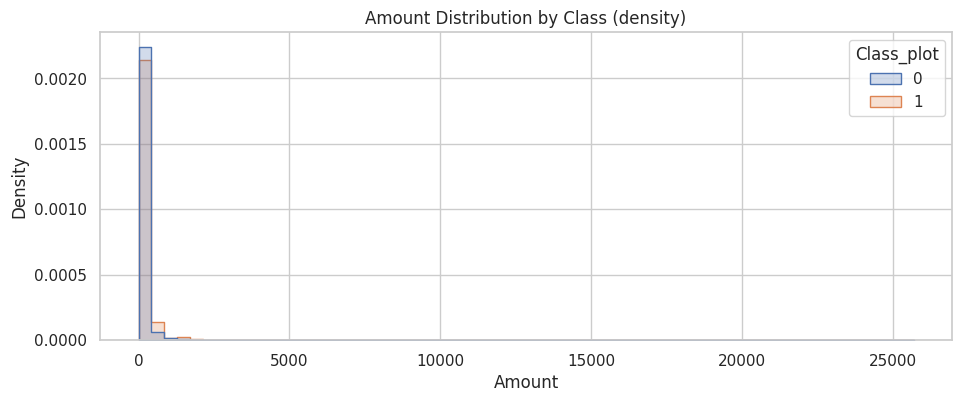

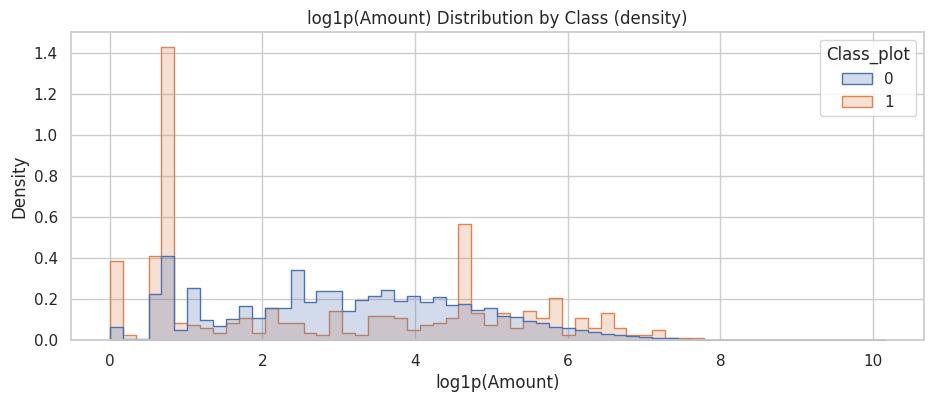

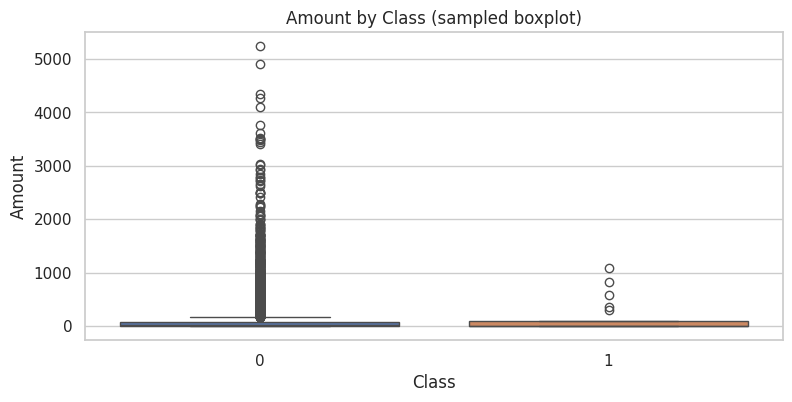

In [9]:
# ============================================================
# Amount distribution by class + log transform + boxplot
# ============================================================

# Make a plotting-safe class label column (always strings)
df_plot["Class_plot"] = df_plot["Class"].astype(str)

# Ensure palette keys match the hue values exactly
PALETTE = {"0": "#4c72b0", "1": "#dd8452"}
HUE_ORDER = ["0", "1"]  # consistent legend/order

# (Optional) Create a log column for cleaner plotting
df_plot["log1p_amount"] = np.log1p(df_plot["Amount"])

plt.figure(figsize=(11, 4))
sns.histplot(
    data=df_plot,
    x="Amount",
    hue="Class_plot",
    hue_order=HUE_ORDER,
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    palette=PALETTE
)
plt.title("Amount Distribution by Class (density)")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(11, 4))
sns.histplot(
    data=df_plot,
    x="log1p_amount",
    hue="Class_plot",
    hue_order=HUE_ORDER,
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    palette=PALETTE
)
plt.title("log1p(Amount) Distribution by Class (density)")
plt.xlabel("log1p(Amount)")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(
    data=df_plot.sample(n=min(15000, len(df_plot)), random_state=RANDOM_STATE),
    x="Class_plot",
    order=HUE_ORDER,
    y="Amount",
    palette=PALETTE
)
plt.title("Amount by Class (sampled boxplot)")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

### Transaction Density: Time vs log1p(Amount) (Hexbin)

Because this dataset is highly imbalanced and contains a very large number of transactions, a standard scatter plot can suffer from **overplotting** (many points overlap and hide structure).  
A **hexbin plot** aggregates points into hexagonal bins and colors each bin by the **number of transactions**, making dense regions easy to spot.

- **X-axis:** `TimeHours` (time elapsed in hours)  
- **Y-axis:** `log1p_amount` (log-transformed amount to reduce skew)  
- **Color intensity:** number of transactions in each bin (darker = more transactions)

This visualization helps reveal where transactions cluster over time and transaction amount ranges.


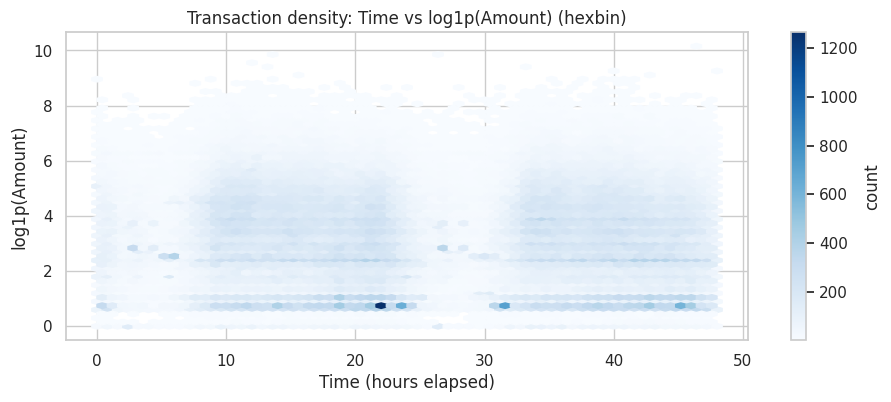

In [10]:
plt.figure(figsize=(11, 4))
plt.hexbin(df_plot["TimeHours"], df_plot["log1p_amount"], gridsize=60, cmap="Blues", mincnt=1)
plt.colorbar(label="count")
plt.title("Transaction density: Time vs log1p(Amount) (hexbin)")
plt.xlabel("Time (hours elapsed)")
plt.ylabel("log1p(Amount)")
plt.show()

Feature engineering is applied before dropping columns. Time-based features are derived from the raw Time column, then the raw Time column is removed from the modeling feature set (as described in the project brief). The Amount column is preserved for cost evaluation while a transformed amount feature is created for modeling.


In [11]:
# Drop unnecessary columns

# Preserve raw Amount for later cost-based evaluation (aligned by index)
amount_series = df["Amount"].copy()

# Time-based feature engineering
SECONDS_PER_DAY = 86400.0
df["hour_of_day"] = (df["Time"] % SECONDS_PER_DAY) / 3600.0
df["sin_hour"] = np.sin(2.0 * np.pi * df["hour_of_day"] / 24.0)
df["cos_hour"] = np.cos(2.0 * np.pi * df["hour_of_day"] / 24.0)

# Amount transform for modeling
df["log1p_amount"] = np.log1p(df["Amount"])

# Drop raw Time from modeling features (Time-derived features retained)
df_model = df.drop(columns=["Time"])

print("Modeling dataframe shape:", df_model.shape)
print("Example columns:", df_model.columns[:10].tolist())

Modeling dataframe shape: (284807, 34)
Example columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']


In [12]:
df_model.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Class,hour_of_day,sin_hour,cos_hour,log1p_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.000000,0.000000,1.0,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.000000,0.000000,1.0,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.000278,0.000073,1.0,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.000278,0.000073,1.0,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.000556,0.000145,1.0,4.262539


### Splitting the data into train & test data

A stratified split preserves the rare fraud class ratio in both training and test partitions. Cost evaluation requires an aligned Amount vector, so the amount series is split using the same indices.


In [13]:
y= df_model["Class"]  #class variable

The train-test split uses stratification to ensure minority class presence in the test set. The same split indices are applied to the raw transaction amounts used in cost-based evaluation.


In [14]:
from sklearn import model_selection

X = df_model.drop(columns=["Class", "Amount"])  # Amount excluded from features; log1p_amount retained
amt = amount_series.loc[df_model.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

amt_train = amt.loc[X_train.index].copy()
amt_test = amt.loc[X_test.index].copy()

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (227845, 32) Test shape: (56962, 32)


##### Preserve X_test & y_test to evaluate on the test data once you build the model

The printed fraud counts validate that stratification preserved minority class representation.


In [15]:
print("\nSanity check (stratification):")
print("Total frauds:", int(y.sum()))
print("Train frauds:", int(y_train.sum()))
print("Test frauds :", int(y_test.sum()))


Sanity check (stratification):
Total frauds: 492
Train frauds: 394
Test frauds : 98


### Plotting the distribution of a variable

A skewness check is applied to training features. Even with PCA components often close to Gaussian, engineered fields such as amount transforms can still show skew. The most skewed variables are selected for visual inspection.


,skewness
V28,9.978409
V8,-8.639485
V23,-6.258558
V2,-4.779484
V17,-3.733377
V21,3.490183
V1,-3.306334
V7,3.152665
V5,-2.786851
V12,-2.286654


Top skewed features selected for plots: ['V28', 'V8', 'V23', 'V2', 'V17', 'V21', 'V1', 'V7', 'V5', 'V12']


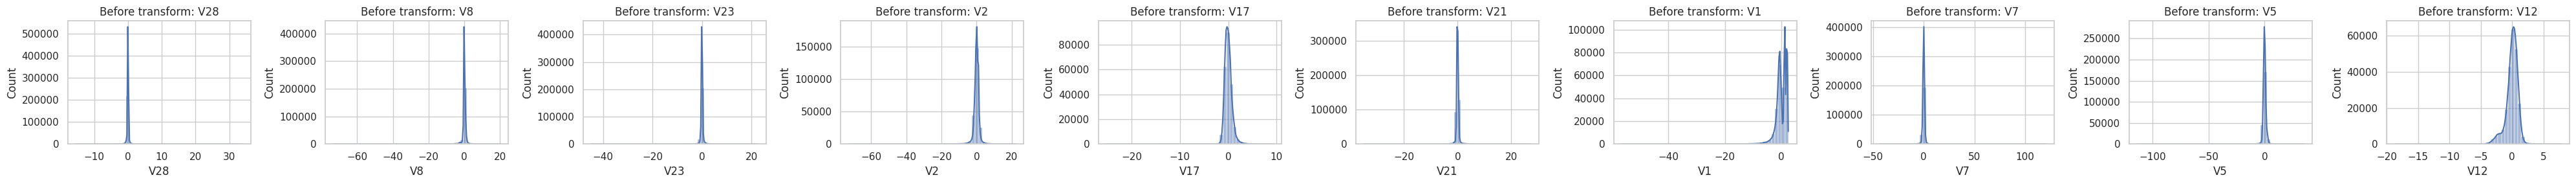

In [16]:
# plot the histogram of a variable from the dataset to see the skewness

# Skewness is computed on training data only to avoid leakage in transform decisions.
skewness = X_train.skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
display(skewness.head(10).to_frame("skewness"))

# Select a few highly skewed features for before/after visualization
TOP_SKEW_FEATURES = skewness.head(10).index.tolist()
print("Top skewed features selected for plots:", TOP_SKEW_FEATURES)

fig, axes = plt.subplots(1, len(TOP_SKEW_FEATURES), figsize=(4*len(TOP_SKEW_FEATURES), 3))
if len(TOP_SKEW_FEATURES) == 1:
    axes = [axes]

for ax, col in zip(axes, TOP_SKEW_FEATURES):
    sns.histplot(X_train[col], bins=50, ax=ax, kde=True, color="#4c72b0")
    ax.set_title(f"Before transform: {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### If there is skewness present in the distribution use:
- <b>Power Transformer</b> package present in the <b>preprocessing library provided by sklearn</b> to make distribution more gaussian

PowerTransformer is fit on training data only and applied to both training and test sets. This mitigates skewness and can improve the behavior of models sensitive to heavy tails.


In [17]:
# - Apply : preprocessing.PowerTransformer(copy=False) to fit & transform the train & test data

pt = preprocessing.PowerTransformer(method="yeo-johnson", copy=False)

X_train_before = X_train.copy()
X_test_before = X_test.copy()

X_train_arr = pt.fit_transform(X_train)
X_test_arr = pt.transform(X_test)

X_train = pd.DataFrame(X_train_arr, columns=X_train_before.columns, index=X_train_before.index)
X_test = pd.DataFrame(X_test_arr, columns=X_test_before.columns, index=X_test_before.index)

skewness_after = X_train.skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
display(skewness_after.head(10).to_frame("skewness_after"))

print("PowerTransformer applied. Shapes:", X_train.shape, X_test.shape)

,skewness_after
V27,3.731696
V7,2.883669
V8,2.382707
V21,-2.076984
V6,-2.001738
V5,-1.349420
V10,-1.329089
V28,1.320690
V20,-0.879795
V17,-0.805442


PowerTransformer applied. Shapes: (227845, 32) (56962, 32)


### skewness reduction after PowerTransformer (train only)

The before/after plots provide visual confirmation of distribution changes after the skewness transformation. The same feature set used in the pre-transform plots is reused for direct comparison.



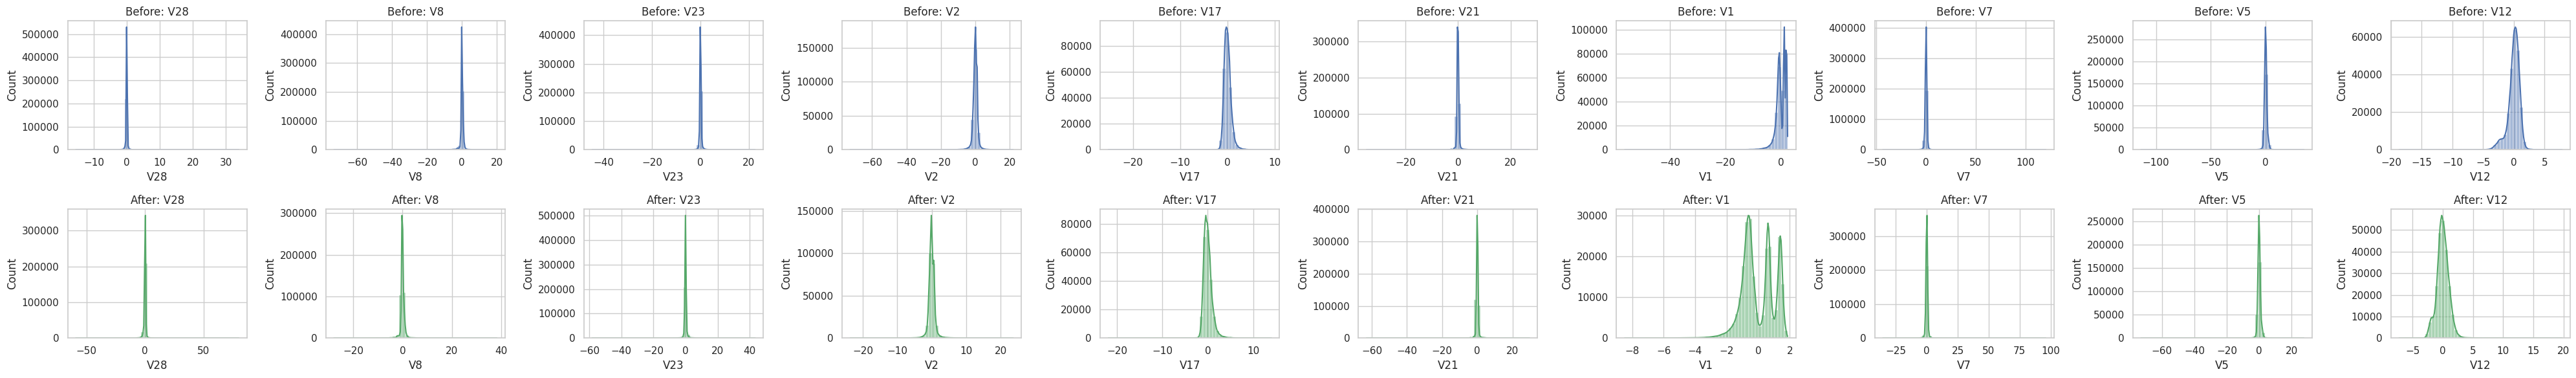

In [18]:
# plot the histogram of a variable from the dataset again to see the result

fig, axes = plt.subplots(2, len(TOP_SKEW_FEATURES), figsize=(4*len(TOP_SKEW_FEATURES), 6))
if len(TOP_SKEW_FEATURES) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for j, col in enumerate(TOP_SKEW_FEATURES):
    sns.histplot(X_train_before[col], bins=50, ax=axes[0, j], kde=True, color="#4c72b0")
    axes[0, j].set_title(f"Before: {col}")
    axes[0, j].set_xlabel(col)

    sns.histplot(X_train[col], bins=50, ax=axes[1, j], kde=True, color="#55a868")
    axes[1, j].set_title(f"After: {col}")
    axes[1, j].set_xlabel(col)

plt.tight_layout()
plt.show()

## Model Building (Imbalanced Dataset)

This section trains and tunes the full model list on **raw imbalanced data** using **stratified cross-validation**, while applying training-time optimizations that do **not** change the evaluation logic.

### Workflow
1. **Run randomized hyperparameter search for each model**
   - Use **multi-metric scoring** in a single CV run:
     - Primary: **ROC-AUC**
     - Supporting: **PR-AUC (Average Precision)**
   - **Inner parallelism enabled**: `RandomizedSearchCV(n_jobs=-1)`

2. **Run model searches concurrently (outer + inner parallelism)**
   - Execute different model searches in parallel using:
     - `joblib.Parallel(n_jobs=OUTER_NJOBS)`
   - **Estimator-level parallelism enabled ** where applicable (`n_jobs=-1` inside models)

3. **Rank and select top models**
   - Build a leaderboard using **mean CV ROC-AUC** (primary) and **mean CV PR-AUC** (supporting).
   - Select **Top-3** models by mean CV ROC-AUC for deeper evaluation.

4. **Top-3 detailed evaluation with ROC-thresholding**
   - Generate **out-of-fold (OOF) predicted probabilities** on the training set.
   - Compute the **ROC curve** from OOF predictions.
   - Choose the classification threshold using **Youden’s J** (`argmax(tpr - fpr)`).
   - Report detailed metrics at the selected threshold:
     - Confusion matrix, precision, recall, F1, accuracy  
     - Reported on **train (OOF)** and **test**.

> Note: These optimizations reduce runtime by eliminating an extra CV pass for PR-AUC, while preserving the same model selection and evaluation methodology.


In [19]:
# Logistic Regression
from sklearn import linear_model #import the package

num_C = [0.01, 0.1, 1.0, 10.0, 100.0]  #--> list of values
cv_num = [3, 5]  #--> list of values

# ============================================================
# Shared modeling utilities (imbalanced + balanced)
# ============================================================

@dataclass
class ModelSpec:
    name: str
    estimator: Any
    param_distributions: Dict[str, Any]
    needs_scaling: bool = True  # Scaling benefits LR/KNN/SVM; harmless for trees

def _make_base_models() -> List[ModelSpec]:
    """Define all requested model families with bounded search spaces."""
    specs: List[ModelSpec] = []

    # Logistic Regression
    specs.append(ModelSpec(
        name="LogisticRegression",
        estimator=LogisticRegression(
            solver="saga",
            max_iter=5000,
            random_state=RANDOM_STATE,
            n_jobs=ESTIMATOR_NJOBS
        ),
        param_distributions={
            "model__C": num_C,
            "model__penalty": ["l1", "l2"],
            "model__class_weight": [None, "balanced"],
        },
        needs_scaling=True
    ))

    # KNN (odd k values)
    specs.append(ModelSpec(
        name="KNN",
        estimator=KNeighborsClassifier(),
        param_distributions={
            "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 21, 31],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],  # 1=Manhattan, 2=Euclidean
        },
        needs_scaling=True
    ))

    # SVM (linear SVM via LinearSVC; decision_function used for ROC / thresholding)
    specs.append(ModelSpec(
        name="LinearSVM",
        estimator=LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=8000
        ),
        param_distributions={
            "model__C": num_C,
            "model__class_weight": [None, "balanced"],
        },
        needs_scaling=True
    ))

    # Decision Tree
    specs.append(ModelSpec(
        name="DecisionTree",
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_distributions={
            "model__max_depth": [3, 5, 7, 9, 12, None],
            "model__min_samples_leaf": [1, 2, 5, 10, 20],
            "model__ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],
            "model__class_weight": [None, "balanced"],
        },
        needs_scaling=False
    ))

    # Random Forest
    specs.append(ModelSpec(
        name="RandomForest",
        estimator=RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=ESTIMATOR_NJOBS
        ),
        param_distributions={
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 6, 10, 14],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.5],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        },
        needs_scaling=False
    ))

    # Gradient Boosted Trees (fast variant)
    specs.append(ModelSpec(
        name="HistGradientBoosting",
        estimator=HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        param_distributions={
            "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
            "model__max_depth": [3, 5, 7, None],
            "model__min_samples_leaf": [20, 50, 100],
            "model__l2_regularization": [0.0, 1e-3, 1e-2, 1e-1],
            "model__max_bins": [128, 255],
        },
        needs_scaling=False
    ))

    # XGBoost
    specs.append(ModelSpec(
        name="XGBoost",
        estimator=xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_estimators=600,
            tree_method="hist",
            device="cuda",
            n_jobs=ESTIMATOR_NJOBS
        ),
        param_distributions={
            "model__n_estimators": [200, 400, 600, 800],
            "model__learning_rate": [0.02, 0.05, 0.1, 0.2],
            "model__max_depth": [3, 4, 5, 6, 8],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0],
            "model__min_child_weight": [1, 5, 10],
            "model__reg_alpha": [0.0, 1e-3, 1e-2, 0.1],
            "model__reg_lambda": [1.0, 2.0, 5.0, 10.0],
        },
        needs_scaling=False
    ))

    return specs

def build_pipeline(estimator: Any, needs_scaling: bool, sampler: Optional[Any] = None) -> Any:
    """
    Build a leakage-safe pipeline.
    - Scaling placed before the estimator when enabled.
    - Sampler placed before the estimator in an imblearn pipeline when provided.
    """
    steps = []
    if needs_scaling:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))

    if sampler is None:
        return Pipeline(steps=steps, memory=memory)   # <-- caching

    imb_steps = []
    if needs_scaling:
        imb_steps.append(("scaler", StandardScaler()))
    imb_steps.append(("sampler", sampler))
    imb_steps.append(("model", estimator))
    return ImbPipeline(steps=imb_steps, memory=memory)  # <-- caching

def get_score_method(estimator: Any) -> str:
    """Select a scoring method supported by the estimator/pipeline."""
    if hasattr(estimator, "predict_proba"):
        return "predict_proba"
    if hasattr(estimator, "decision_function"):
        return "decision_function"
    return "predict"

def extract_positive_scores(raw_output: Any) -> np.ndarray:
    """Convert model output into 1D scores for the positive class."""
    raw_output = np.asarray(raw_output)
    if raw_output.ndim == 2 and raw_output.shape[1] >= 2:
        return raw_output[:, 1]
    return raw_output.ravel()

def compute_basic_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Compute standard classification metrics."""
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }

def run_random_search(
    spec: ModelSpec,
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    cv: StratifiedKFold,
    sampler: Optional[Any] = None,
    n_iter: int = 18,
    scoring: str = "roc_auc",
    verbose: int = 0
) -> Dict[str, Any]:
    """
    Execute randomized search for a single model spec.
    Parallelism policy:
      - OUTER parallelism handled by joblib.Parallel
      - INNER parallelism enabled (n_jobs=-1)
    """
    pipe = build_pipeline(spec.estimator, spec.needs_scaling, sampler=sampler)

    # Multi-metric scoring: get ROC-AUC and PR-AUC in the SAME CV run:contentReference[oaicite:20]{index=20}
    scoring_dict = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}
    refit_metric = scoring if isinstance(scoring, str) else "roc_auc"

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=spec.param_distributions,
        n_iter=n_iter,
        scoring=scoring_dict,
        refit=refit_metric,
        cv=cv,
        n_jobs=INNER_NJOBS,
        verbose=verbose,
        random_state=RANDOM_STATE,
        return_train_score=False
    )

    t0 = time.time()
    search.fit(Xtr, ytr)
    fit_time = time.time() - t0

    best_est = search.best_estimator_
    best_params = search.best_params_
    best_auc = float(search.best_score_)

    best_idx = search.best_index_
    pr_auc = float(search.cv_results_[f"mean_test_pr_auc"][best_idx])

    return {
        "model_name": spec.name,
        "best_estimator": best_est,
        "cv_roc_auc": best_auc,
        "cv_pr_auc": pr_auc,
        "best_params": best_params,
        "fit_time_sec": fit_time,
    }

# Cross-validation configuration (minority class representation preserved via stratification)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Model specs list
MODEL_SPECS = _make_base_models()

print("Model specs prepared:", [m.name for m in MODEL_SPECS])

Model specs prepared: ['LogisticRegression', 'KNN', 'LinearSVM', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'XGBoost']


## Persistant Training

If runtime disconnects after (say) 4/7 imbalanced models finished → rerun loads those 4 from PERSIST_IMB and trains only remaining 3.

Same for balanced: each (sampler, model) combo is cached separately in PERSIST_BAL.

Once completed, reruns don’t train again; they load from Drive.

In [20]:
import os, json, time
from pathlib import Path
import joblib
import fcntl  # Colab/Linux file locks

def _safe(s: str) -> str:
    return "".join(c if c.isalnum() or c in ("-", "_", "+") else "_" for c in str(s))

class _Lock:
    def __init__(self, path: Path):
        self.path = Path(path)
        self.fh = None
    def __enter__(self):
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self.fh = open(self.path, "w")
        fcntl.flock(self.fh.fileno(), fcntl.LOCK_EX)
        return self
    def __exit__(self, exc_type, exc, tb):
        fcntl.flock(self.fh.fileno(), fcntl.LOCK_UN)
        self.fh.close()

def _atomic_dump(obj, out_path: Path):
    out_path = Path(out_path)
    tmp = out_path.with_suffix(out_path.suffix + f".tmp.{os.getpid()}")
    joblib.dump(obj, tmp)
    os.replace(tmp, out_path)  # atomic

def _fingerprint_for_task(*, stage: str, spec, sampler_name: str, n_iter: int, scoring: str, cv, Xtr):
    # fingerprint changes when you change anything important => retrain automatically
    cfg = {
        "stage": stage,
        "model": getattr(spec, "name", str(spec)),
        "sampler": sampler_name,
        "n_iter": n_iter,
        "scoring": scoring,
        "cv": {"type": type(cv).__name__, "n_splits": getattr(cv, "n_splits", None),
               "shuffle": getattr(cv, "shuffle", None), "random_state": getattr(cv, "random_state", None)},
        "X_shape": tuple(Xtr.shape),
        "X_cols": list(map(str, getattr(Xtr, "columns", range(Xtr.shape[1])))),
        "param_space": getattr(spec, "param_distributions", None),
    }
    return joblib.hash(cfg, hash_name="md5")[:16]

def run_random_search_cached(
    *,
    stage: str,                 # "imbalanced" or "balanced"
    persist_dir: str,
    spec,
    Xtr, ytr, cv,
    sampler=None,
    sampler_name: str = "None",
    n_iter: int = 18,
    scoring: str = "roc_auc",
    verbose: int = 0,
    force_retrain: bool = False,
):
    persist_dir = Path(persist_dir)
    persist_dir.mkdir(parents=True, exist_ok=True)

    model_name = getattr(spec, "name", str(spec))
    fp = _fingerprint_for_task(stage=stage, spec=spec, sampler_name=sampler_name, n_iter=n_iter,
                               scoring=scoring, cv=cv, Xtr=Xtr)

    key = _safe(f"{stage}__{sampler_name}__{model_name}__{fp}")
    artifact = persist_dir / f"{key}.joblib"
    meta = persist_dir / f"{key}.meta.json"
    lock = persist_dir / f"{key}.lock"

    with _Lock(lock):
        if artifact.exists() and not force_retrain:
            out = joblib.load(artifact)
            out = dict(out)
            out["_persist_status"] = "loaded"
            out["_persist_artifact"] = str(artifact)
            return out

        t0 = time.time()
        out = run_random_search(   # <-- your existing function
            spec=spec, Xtr=Xtr, ytr=ytr, cv=cv,
            sampler=sampler, n_iter=n_iter, scoring=scoring, verbose=verbose
        )
        out = dict(out)
        out["_persist_status"] = "trained"
        out["_persist_artifact"] = str(artifact)
        out["_persist_fingerprint"] = fp
        out["_persist_elapsed_sec"] = round(time.time() - t0, 3)
        out["_persist_trained_at_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())

        _atomic_dump(out, artifact)
        meta.write_text(json.dumps({
            "stage": stage,
            "sampler": sampler_name,
            "model": out.get("model_name", model_name),
            "cv_roc_auc": out.get("cv_roc_auc"),
            "cv_pr_auc": out.get("cv_pr_auc"),
            "fit_time_sec": out.get("fit_time_sec"),
            "best_params": out.get("best_params"),
            "artifact": str(artifact),
            "trained_at_utc": out["_persist_trained_at_utc"],
        }, indent=2), encoding="utf-8")

        return out

#### Perform cross-validation on `X_train` & `y_train` to create:
- `X_train_cv`
- `X_test_cv`
- `y_train_cv`
- `y_test_cv`

We perform a **Stratified split** of the training set into CV folds so that each fold preserves the fraud/non-fraud ratio. For each fold, we obtain:

- `X_train_cv`, `y_train_cv` → fold-specific training data  
- `X_test_cv`, `y_test_cv` → fold-specific validation data (used for evaluation within CV)

✅ **Scalable training pattern (outer + Inner parallelism)**  
To reduce training time without compromising evaluation quality:

- **Outer parallelism:** each model (or sampler+model) search runs concurrently using `joblib.Parallel(n_jobs=OUTER_NJOBS)`
- **Inner parallelism:** enabled  
  - `RandomizedSearchCV(n_jobs=-1)`  
  - estimator `n_jobs=-1` (where supported)


In [21]:
#perform cross validation
#perform hyperparameter tuning
#print the evaluation result by choosing a evaluation metric
#print the optimum value of hyperparameters

# ============================================================
# Imbalanced training: outer-parallel randomized searches
# ============================================================

print("Starting imbalanced model searches (outer + Inner parallelism enabled)...")

imbalanced_results = Parallel(n_jobs=OUTER_NJOBS, verbose=10)(
    delayed(run_random_search_cached)(
        stage="imbalanced",
        persist_dir=PERSIST_IMB,
        spec=m,
        Xtr=X_train,
        ytr=y_train,
        cv=skf,
        sampler=None,
        sampler_name="None",
        n_iter=16,
        scoring="roc_auc",
        verbose=0,
        force_retrain=False,   # set True if you want to ignore cache
    )
    for m in MODEL_SPECS
)

imbalanced_leaderboard = pd.DataFrame([{
    "model": r["model_name"],
    "cv_roc_auc": r["cv_roc_auc"],
    "cv_pr_auc": r["cv_pr_auc"],
    "fit_time_sec": r["fit_time_sec"],
} for r in imbalanced_results]).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)

print("\nImbalanced leaderboard (sorted by CV ROC-AUC):")
display(imbalanced_leaderboard)

imbalanced_map = {r["model_name"]: r for r in imbalanced_results}

top3_imbal_models = imbalanced_leaderboard["model"].head(3).tolist()
print("Top 3 imbalanced models:", top3_imbal_models)

Starting imbalanced model searches (outer + Inner parallelism enabled)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed:    1.6s remaining:    4.1s
[Parallel(n_jobs=-1)]: Done   3 out of   7 | elapsed:    1.8s remaining:    2.3s



Imbalanced leaderboard (sorted by CV ROC-AUC):


[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    1.9s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done   5 out of   7 | elapsed:    2.0s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    2.0s finished


,model,cv_roc_auc,cv_pr_auc,fit_time_sec
0,XGBoost,0.985389,0.849373,234.031573
1,RandomForest,0.984333,0.772330,14670.818288
2,LogisticRegression,0.981906,0.754351,13575.066561
3,LinearSVM,0.980736,0.755778,82.739685
4,HistGradientBoosting,0.976569,0.811770,254.082296
5,DecisionTree,0.947116,0.287701,593.738666
6,KNN,0.928508,0.821024,6529.634797


Top 3 imbalanced models: ['XGBoost', 'RandomForest', 'LogisticRegression']


#### Proceed with the model which shows the best result
- Apply the best hyperparameter on the model
- Predict on the test dataset

The best imbalanced model is selected by mean CV ROC-AUC. Detailed threshold-based metrics are computed using out-of-fold training scores to reduce optimistic bias.


In [22]:
# ============================================================
# Imbalanced top-3: ROC threshold selection (Youden's J) + metrics
# ============================================================

from threadpoolctl import threadpool_limits

def oof_scores_for_estimator(estimator: Any, Xtr: pd.DataFrame, ytr: pd.Series, cv: StratifiedKFold) -> np.ndarray:
    method = get_score_method(estimator)
    with threadpool_limits(limits=-1):
        raw = cross_val_predict(
            estimator, Xtr, ytr,
            cv=cv, method=method,
            n_jobs=INNER_NJOBS,
            verbose=0
        )
    return extract_positive_scores(raw)

def fit_and_get_test_scores(estimator: Any, Xtr: pd.DataFrame, ytr: pd.Series, Xte: pd.DataFrame) -> np.ndarray:
    """Fit estimator on full training data and return test scores."""
    est = estimator
    est.fit(Xtr, ytr)
    if hasattr(est, "predict_proba"):
        return est.predict_proba(Xte)[:, 1]
    if hasattr(est, "decision_function"):
        return est.decision_function(Xte)
    return est.predict(Xte)

def best_threshold_from_roc(y_true: np.ndarray, scores: np.ndarray) -> float:
    """Compute Youden's J threshold: argmax(tpr - fpr)."""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    j = tpr - fpr
    return float(thresholds[np.argmax(j)])

def threshold_metrics_report(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> Dict[str, Any]:
    """Compute metrics at a given threshold."""
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    m = compute_basic_metrics(y_true, y_pred)
    m.update({
        "threshold": float(threshold),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })
    return m

imbalanced_top3_reports = []

for model_name in top3_imbal_models:
    best_est = imbalanced_map[model_name]["best_estimator"]

    oof_scores = oof_scores_for_estimator(best_est, X_train, y_train, skf)
    roc_thr = best_threshold_from_roc(y_train.values, oof_scores)

    train_rep = threshold_metrics_report(y_train.values, oof_scores, roc_thr)

    test_scores = fit_and_get_test_scores(best_est, X_train, y_train, X_test)
    test_rep = threshold_metrics_report(y_test.values, test_scores, roc_thr)

    test_roc_auc = float(roc_auc_score(y_test, test_scores))
    test_pr_auc = float(average_precision_score(y_test, test_scores))

    imbalanced_top3_reports.append({
        "model": model_name,
        "cv_roc_auc": imbalanced_map[model_name]["cv_roc_auc"],
        "cv_pr_auc": imbalanced_map[model_name]["cv_pr_auc"],
        "roc_threshold(train_oof)": roc_thr,
        "train_precision(oof)": train_rep["precision"],
        "train_recall(oof)": train_rep["recall"],
        "train_f1(oof)": train_rep["f1"],
        "test_roc_auc": test_roc_auc,
        "test_pr_auc": test_pr_auc,
        "test_precision": test_rep["precision"],
        "test_recall": test_rep["recall"],
        "test_f1": test_rep["f1"],
        "test_accuracy": test_rep["accuracy"],
        "test_confusion": f"TN={test_rep['tn']}, FP={test_rep['fp']}, FN={test_rep['fn']}, TP={test_rep['tp']}",
    })

imbalanced_top3_table = pd.DataFrame(imbalanced_top3_reports).sort_values("cv_roc_auc", ascending=False)
print("Top 3 (imbalanced) threshold-based report:")
display(imbalanced_top3_table)

best_model_name = imbalanced_leaderboard.iloc[0]["model"]
best_imbal_estimator = imbalanced_map[best_model_name]["best_estimator"]

print("Selected best imbalanced model:", best_model_name)

Top 3 (imbalanced) threshold-based report:


,model,cv_roc_auc,cv_pr_auc,roc_threshold(train_oof),train_precision(oof),train_recall(oof),train_f1(oof),test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_accuracy,test_confusion
0,XGBoost,0.985389,0.849373,0.001157,0.049251,0.926396,0.093530,0.981191,0.874668,0.047594,0.918367,0.090498,0.968242,"TN=55063, FP=1801, FN=8, TP=90"
1,RandomForest,0.984333,0.772330,0.161136,0.051697,0.916244,0.097872,0.978678,0.763816,0.042032,0.928571,0.080424,0.963467,"TN=54790, FP=2074, FN=7, TP=91"
2,LogisticRegression,0.981906,0.754351,0.436574,0.042431,0.921320,0.081126,0.971612,0.713072,0.038247,0.908163,0.073402,0.960553,"TN=54626, FP=2238, FN=9, TP=89"


Selected best imbalanced model: XGBoost


This cell instantiates the selected best imbalanced model with tuned hyperparameters, fits on the full training data, and prints a threshold-independent evaluation score (ROC-AUC) on the test set. This preserves the starter notebook flow while keeping the main selection based on cross-validated ROC-AUC.


In [23]:
clf = best_imbal_estimator  #initialise the model with optimum hyperparameters
clf.fit(X_train, y_train)

if hasattr(clf, "predict_proba"):
    test_scores_best = clf.predict_proba(X_test)[:, 1]
elif hasattr(clf, "decision_function"):
    test_scores_best = clf.decision_function(X_test)
else:
    test_scores_best = clf.predict(X_test)

print("Test ROC-AUC:", roc_auc_score(y_test, test_scores_best))
print("Test PR-AUC :", average_precision_score(y_test, test_scores_best))

Test ROC-AUC: 0.9811907106680602
Test PR-AUC : 0.8746682641679622


### Print the important features of the best model to understand the dataset
- This will not give much explanation on the already transformed dataset
- But it will help us in understanding if the dataset is not PCA transformed

This section attempts to extract feature importance using:
- `feature_importances_` when available (trees, XGBoost)
- absolute coefficients when available (linear models)
- permutation importance as a fallback


Top 10 important features (proxy importance):


,importance
V14,0.322982
V10,0.209109
V12,0.118093
V17,0.077757
V4,0.047717
V3,0.018000
V11,0.016456
V7,0.011521
V8,0.010943
V20,0.010405


Top var = 14 -> V14
2nd Top var = 10 -> V10


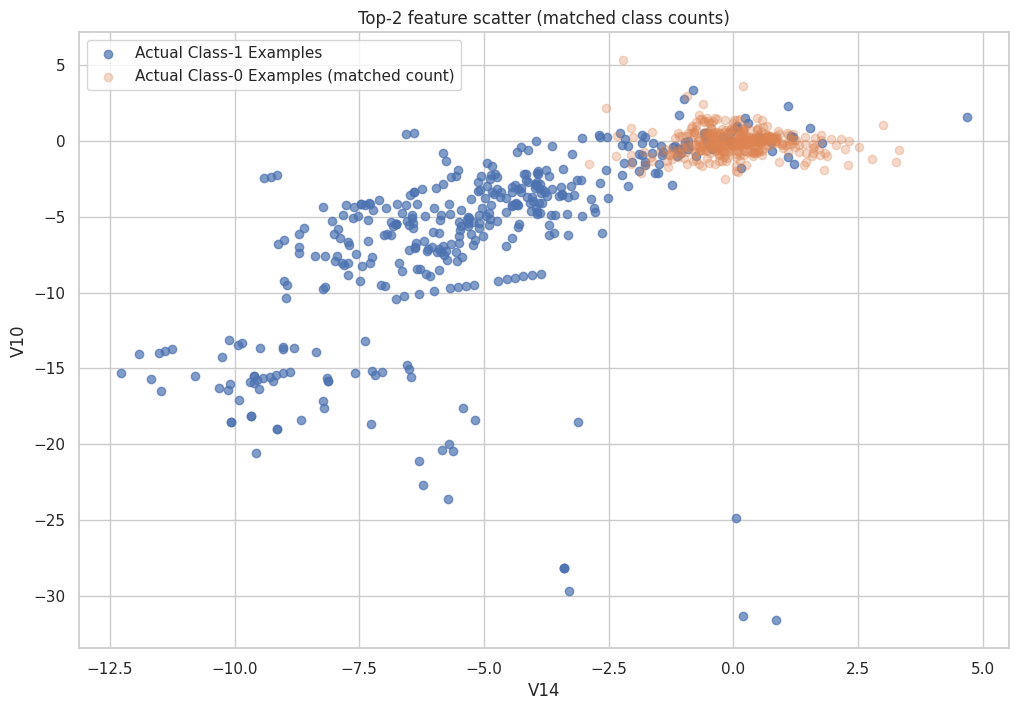

In [24]:
from sklearn.inspection import permutation_importance

def get_feature_importance_vector(estimator: Any, Xref: pd.DataFrame, yref: pd.Series) -> np.ndarray:
    """Return a feature-importance-like vector for the estimator."""
    base_est = estimator
    if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
        base_est = estimator.named_steps["model"]

    if hasattr(base_est, "feature_importances_"):
        return np.asarray(base_est.feature_importances_, dtype=float)

    if hasattr(base_est, "coef_"):
        coefs = np.asarray(base_est.coef_, dtype=float)
        if coefs.ndim == 2:
            coefs = coefs[0]
        return np.abs(coefs)

    Xs = Xref.sample(n=min(20000, len(Xref)), random_state=RANDOM_STATE)
    ys = yref.loc[Xs.index]
    perm = permutation_importance(estimator, Xs, ys, n_repeats=5, random_state=RANDOM_STATE, n_jobs=GLOBAL_NJOBS)
    return np.asarray(perm.importances_mean, dtype=float)

feature_names = X_train.columns.tolist()
importances = get_feature_importance_vector(clf, X_train, y_train)

if importances.shape[0] != len(feature_names):
    raise RuntimeError("Importance vector length mismatch; feature mapping cannot be constructed safely.")

imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 10 important features (proxy importance):")
display(imp_series.head(10).to_frame("importance"))

top_var_index = int(np.argmax(importances))
second_top_var_index = int(np.argsort(importances)[-2])

print("Top var =", top_var_index + 1, "->", feature_names[top_var_index])
print("2nd Top var =", second_top_var_index + 1, "->", feature_names[second_top_var_index])

X_train_1 = X_train.to_numpy()[np.where(y_train.to_numpy()==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train.to_numpy()==0.0)]

np.random.shuffle(X_train_0)

plt.rcParams['figure.figsize'] = [12, 8]
plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], label='Actual Class-1 Examples', alpha=0.7)
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples (matched count)', alpha=0.3)
plt.title("Top-2 feature scatter (matched class counts)")
plt.xlabel(feature_names[top_var_index])
plt.ylabel(feature_names[second_top_var_index])
plt.legend()
plt.show()

## Model building with balancing Classes

##### Perform class balancing with :
- Random Oversampling
- SMOTE
- ADASYN

## Model Building
- Build different models on the balanced dataset and see the result

In [25]:
# Logistic Regression
from sklearn import linear_model #import the package

num_C = [0.01, 0.1, 1.0, 10.0, 100.0]  #--> list of values
cv_num = [3, 5]  #--> list of values

# ============================================================
# Balanced training: RandomOverSampler, SMOTE, ADASYN
# ============================================================

SAMPLERS = {
    "RandomOverSampler": RandomOverSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "ADASYN": ADASYN(random_state=RANDOM_STATE),
}

def run_sampler_model_search(sampler_name: str, sampler, spec):
    out = run_random_search_cached(
        stage="balanced",
        persist_dir=PERSIST_BAL,
        spec=spec,
        Xtr=X_train,
        ytr=y_train,
        cv=skf,
        sampler=sampler,
        sampler_name=sampler_name,
        n_iter=16,
        scoring="roc_auc",
        verbose=0,
        force_retrain=False,
    )
    out["sampler"] = sampler_name
    return out

print("Starting balanced model searches for all samplers (outer + inner parallelism enabled)...")

balanced_results = Parallel(n_jobs=OUTER_NJOBS, verbose=10)(
    delayed(run_sampler_model_search)(s_name, s_obj, m_spec)
    for s_name, s_obj in SAMPLERS.items()
    for m_spec in MODEL_SPECS
)

balanced_leaderboard = pd.DataFrame([{
    "sampler": r["sampler"],
    "model": r["model_name"],
    "cv_roc_auc": r["cv_roc_auc"],
    "cv_pr_auc": r["cv_pr_auc"],
    "fit_time_sec": r["fit_time_sec"],
} for r in balanced_results]).sort_values(["cv_roc_auc"], ascending=False).reset_index(drop=True)

print("\nBalanced leaderboard (sorted by CV ROC-AUC):")
display(balanced_leaderboard)

balanced_map = {(r["sampler"], r["model_name"]): r for r in balanced_results}

best_bal_row = balanced_leaderboard.iloc[0]
best_bal_sampler = best_bal_row["sampler"]
best_bal_model = best_bal_row["model"]
best_bal_estimator = balanced_map[(best_bal_sampler, best_bal_model)]["best_estimator"]

print("Selected best balanced combo:", f"{best_bal_sampler}+{best_bal_model}")

Starting balanced model searches for all samplers (outer + inner parallelism enabled)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  21 | elapsed:    2.3s remaining:    9.6s
[Parallel(n_jobs=-1)]: Done   7 out of  21 | elapsed:    2.3s remaining:    4.7s
[Parallel(n_jobs=-1)]: Done  10 out of  21 | elapsed:    2.4s remaining:    2.6s
[Parallel(n_jobs=-1)]: Done  13 out of  21 | elapsed:    2.5s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done  16 out of  21 | elapsed:    2.6s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done  19 out of  21 | elapsed:    3.3s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  21 out of  21 | elapsed:    3.9s finished



Balanced leaderboard (sorted by CV ROC-AUC):


,sampler,model,cv_roc_auc,cv_pr_auc,fit_time_sec
0,SMOTE,RandomForest,0.986069,0.843198,50434.884678
1,ADASYN,XGBoost,0.984036,0.848536,872.551119
2,ADASYN,RandomForest,0.983987,0.821943,51685.754799
3,SMOTE,XGBoost,0.983780,0.851139,983.952069
4,RandomOverSampler,RandomForest,0.983772,0.786808,33784.935483
5,RandomOverSampler,XGBoost,0.983241,0.844981,937.354649
6,SMOTE,HistGradientBoosting,0.983046,0.759149,1736.749453
7,ADASYN,HistGradientBoosting,0.982620,0.804686,1863.098361
8,RandomOverSampler,LogisticRegression,0.981674,0.763123,8276.922891
9,RandomOverSampler,HistGradientBoosting,0.980952,0.747359,1716.479988


Selected best balanced combo: SMOTE+RandomForest


#### perfom cross validation on the X_train & y_train to create:
- X_train_cv
- X_test_cv
- y_train_cv
- y_test_cv

The balanced stage is evaluated in the same manner as the imbalanced stage:
- Top combinations are ranked by mean CV ROC-AUC
- Top-3 combinations are expanded with ROC-threshold metrics derived from training out-of-fold scores


### Random Oversampling

In [26]:
from imblearn import over_sampling #- import the packages

#perform cross validation & then balance classes on X_train_cv & y_train_cv using Random Oversampling

# Demonstration: class distribution after RandomOverSampler
ros = over_sampling.RandomOverSampler(random_state=RANDOM_STATE)
X_ros_demo, y_ros_demo = ros.fit_resample(X_train, y_train)

print("Class distribution (train) before oversampling:")
print(y_train.value_counts())
print("\nClass distribution (train) after RandomOverSampler:")
print(pd.Series(y_ros_demo).value_counts())

Class distribution (train) before oversampling:
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution (train) after RandomOverSampler:
Class
0    227451
1    227451
Name: count, dtype: int64


### Print the class distribution after applying SMOTE


Class distribution (train) after SMOTE:
0    227451
1    227451
Name: count, dtype: int64


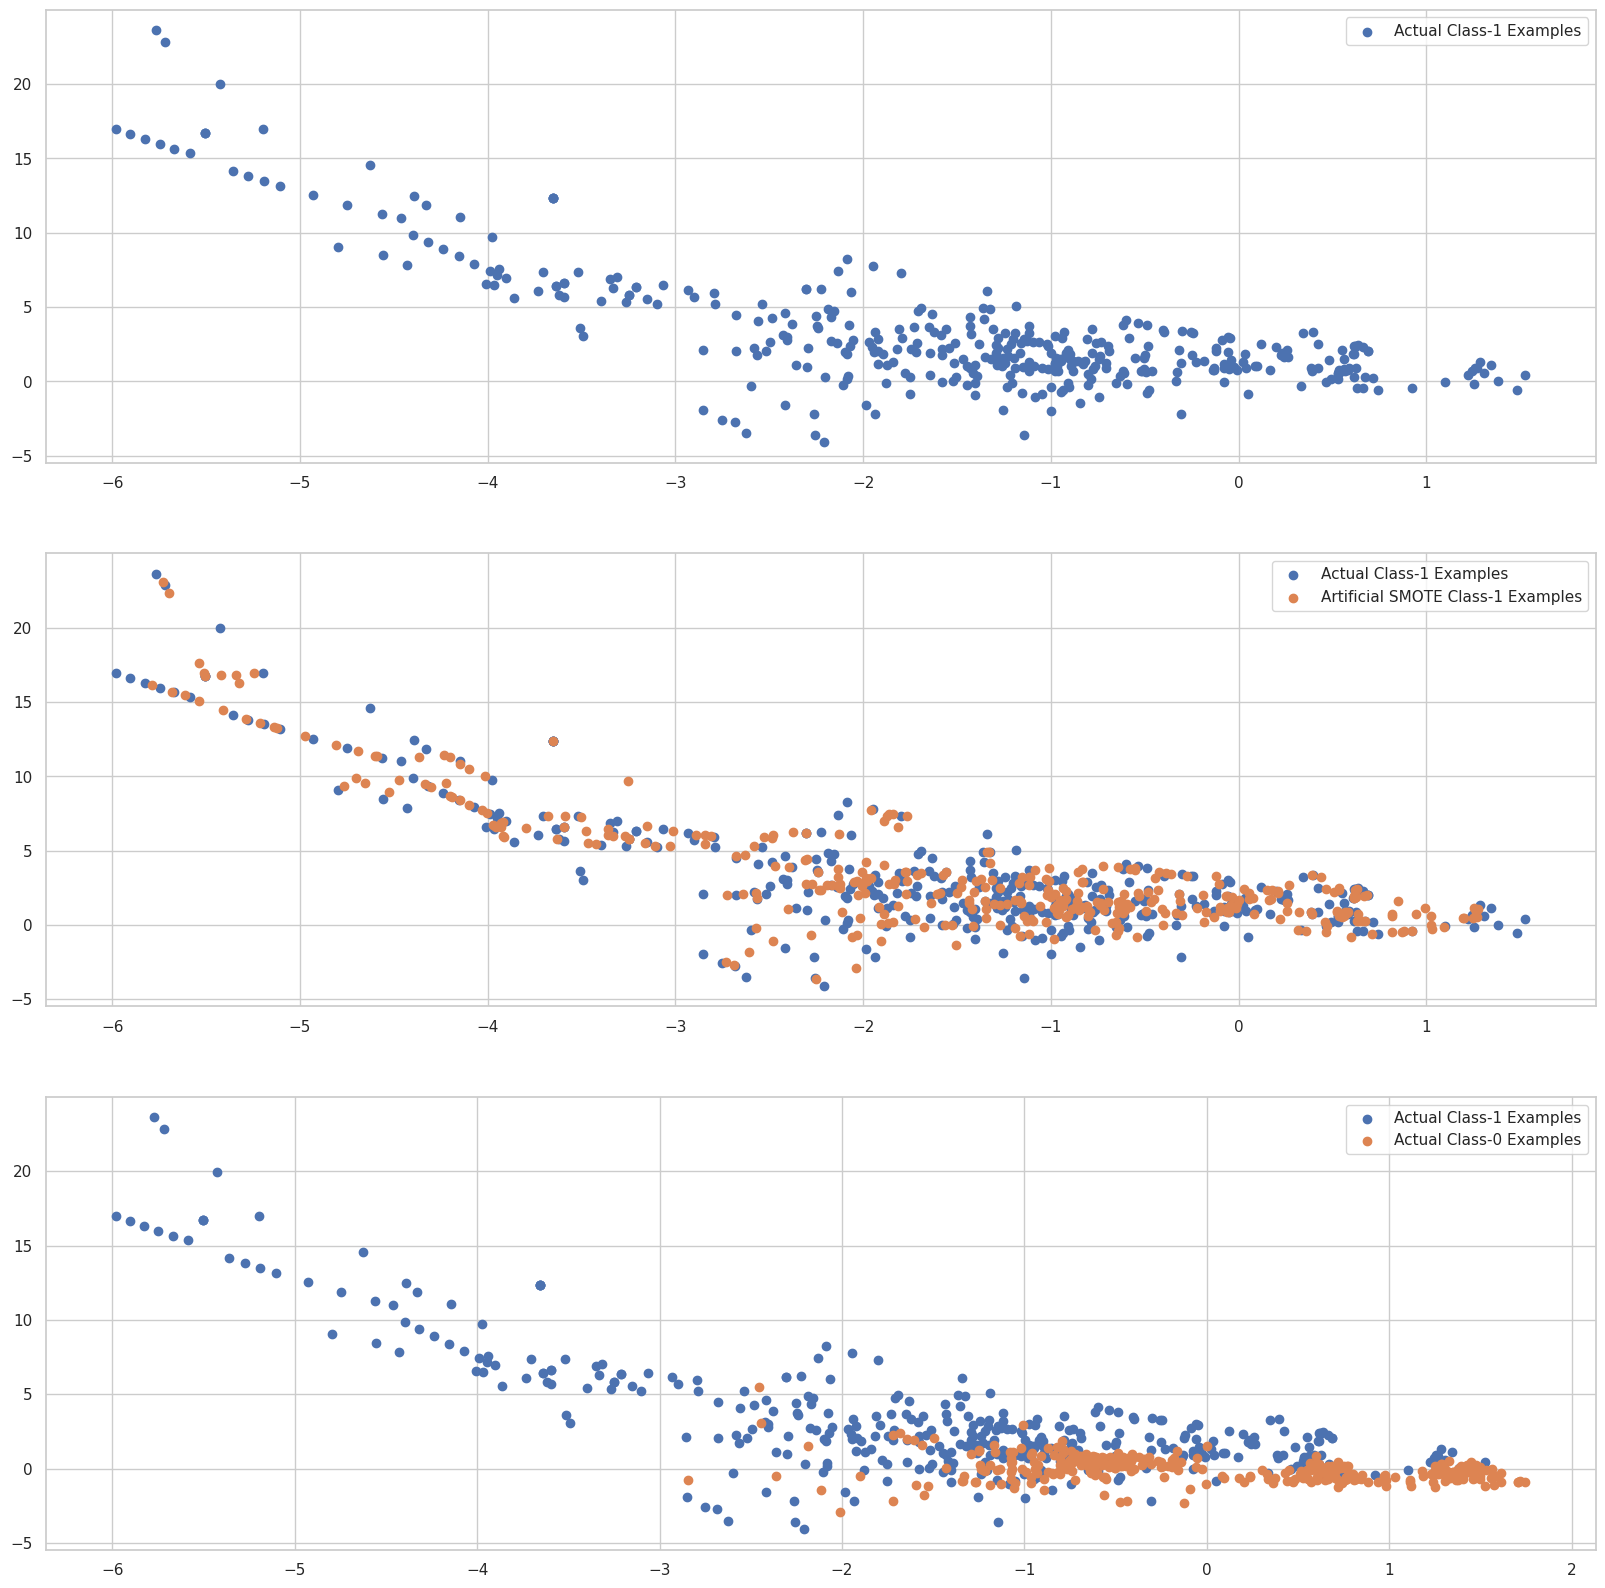

In [27]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

sm = over_sampling.SMOTE(random_state=0)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Convert to NumPy arrays explicitly (avoids pandas indexing issues)
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

X_train_smote_np = np.asarray(X_train_smote)   # works whether it is DataFrame or ndarray
y_train_smote_np = np.asarray(y_train_smote)

# Artificial minority samples appended after original samples
X_train_smote_1 = X_train_smote_np[X_train_np.shape[0]:]

# Split original train into class-1 and class-0 arrays
X_train_1 = X_train_np[y_train_np == 1]
X_train_0 = X_train_np[y_train_np == 0]

np.random.shuffle(X_train_0)

plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(
    X_train_smote_1[:X_train_1.shape[0], 0],
    X_train_smote_1[:X_train_1.shape[0], 1],
    label='Artificial SMOTE Class-1 Examples'
)
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(
    X_train_0[:X_train_1.shape[0], 0],
    X_train_0[:X_train_1.shape[0], 1],
    label='Actual Class-0 Examples'
)
plt.legend()

print("\nClass distribution (train) after SMOTE:")
print(pd.Series(y_train_smote_np).value_counts())

This placeholder cell is retained from the starter notebook. The main SMOTE model training is already executed in the balanced leaderboard stage using leakage-safe CV pipelines. This cell is kept for structural alignment and serves as a pointer to the earlier leaderboard results.


In [28]:
#perform cross validation & then balance classes on X_train_cv & y_train_cv using SMOTE
#perform hyperparameter tuning
#print the evaluation result by choosing a evaluation metric
#print the optimum value of hyperparameters

smote_rows = balanced_leaderboard[balanced_leaderboard["sampler"] == "SMOTE"].reset_index(drop=True)
print("SMOTE leaderboard (subset):")
display(smote_rows)

SMOTE leaderboard (subset):


,sampler,model,cv_roc_auc,cv_pr_auc,fit_time_sec
0,SMOTE,RandomForest,0.986069,0.843198,50434.884678
1,SMOTE,XGBoost,0.983780,0.851139,983.952069
2,SMOTE,HistGradientBoosting,0.983046,0.759149,1736.749453
3,SMOTE,LogisticRegression,0.979886,0.759834,9223.455037
4,SMOTE,LinearSVM,0.979071,0.754758,245.478778
5,SMOTE,DecisionTree,0.965780,0.430405,4207.186430
6,SMOTE,KNN,0.947826,0.611617,29316.248033


### Print the class distribution after applying ADASYN


Class distribution (train) after ADASYN:
1    227455
0    227451
Name: count, dtype: int64


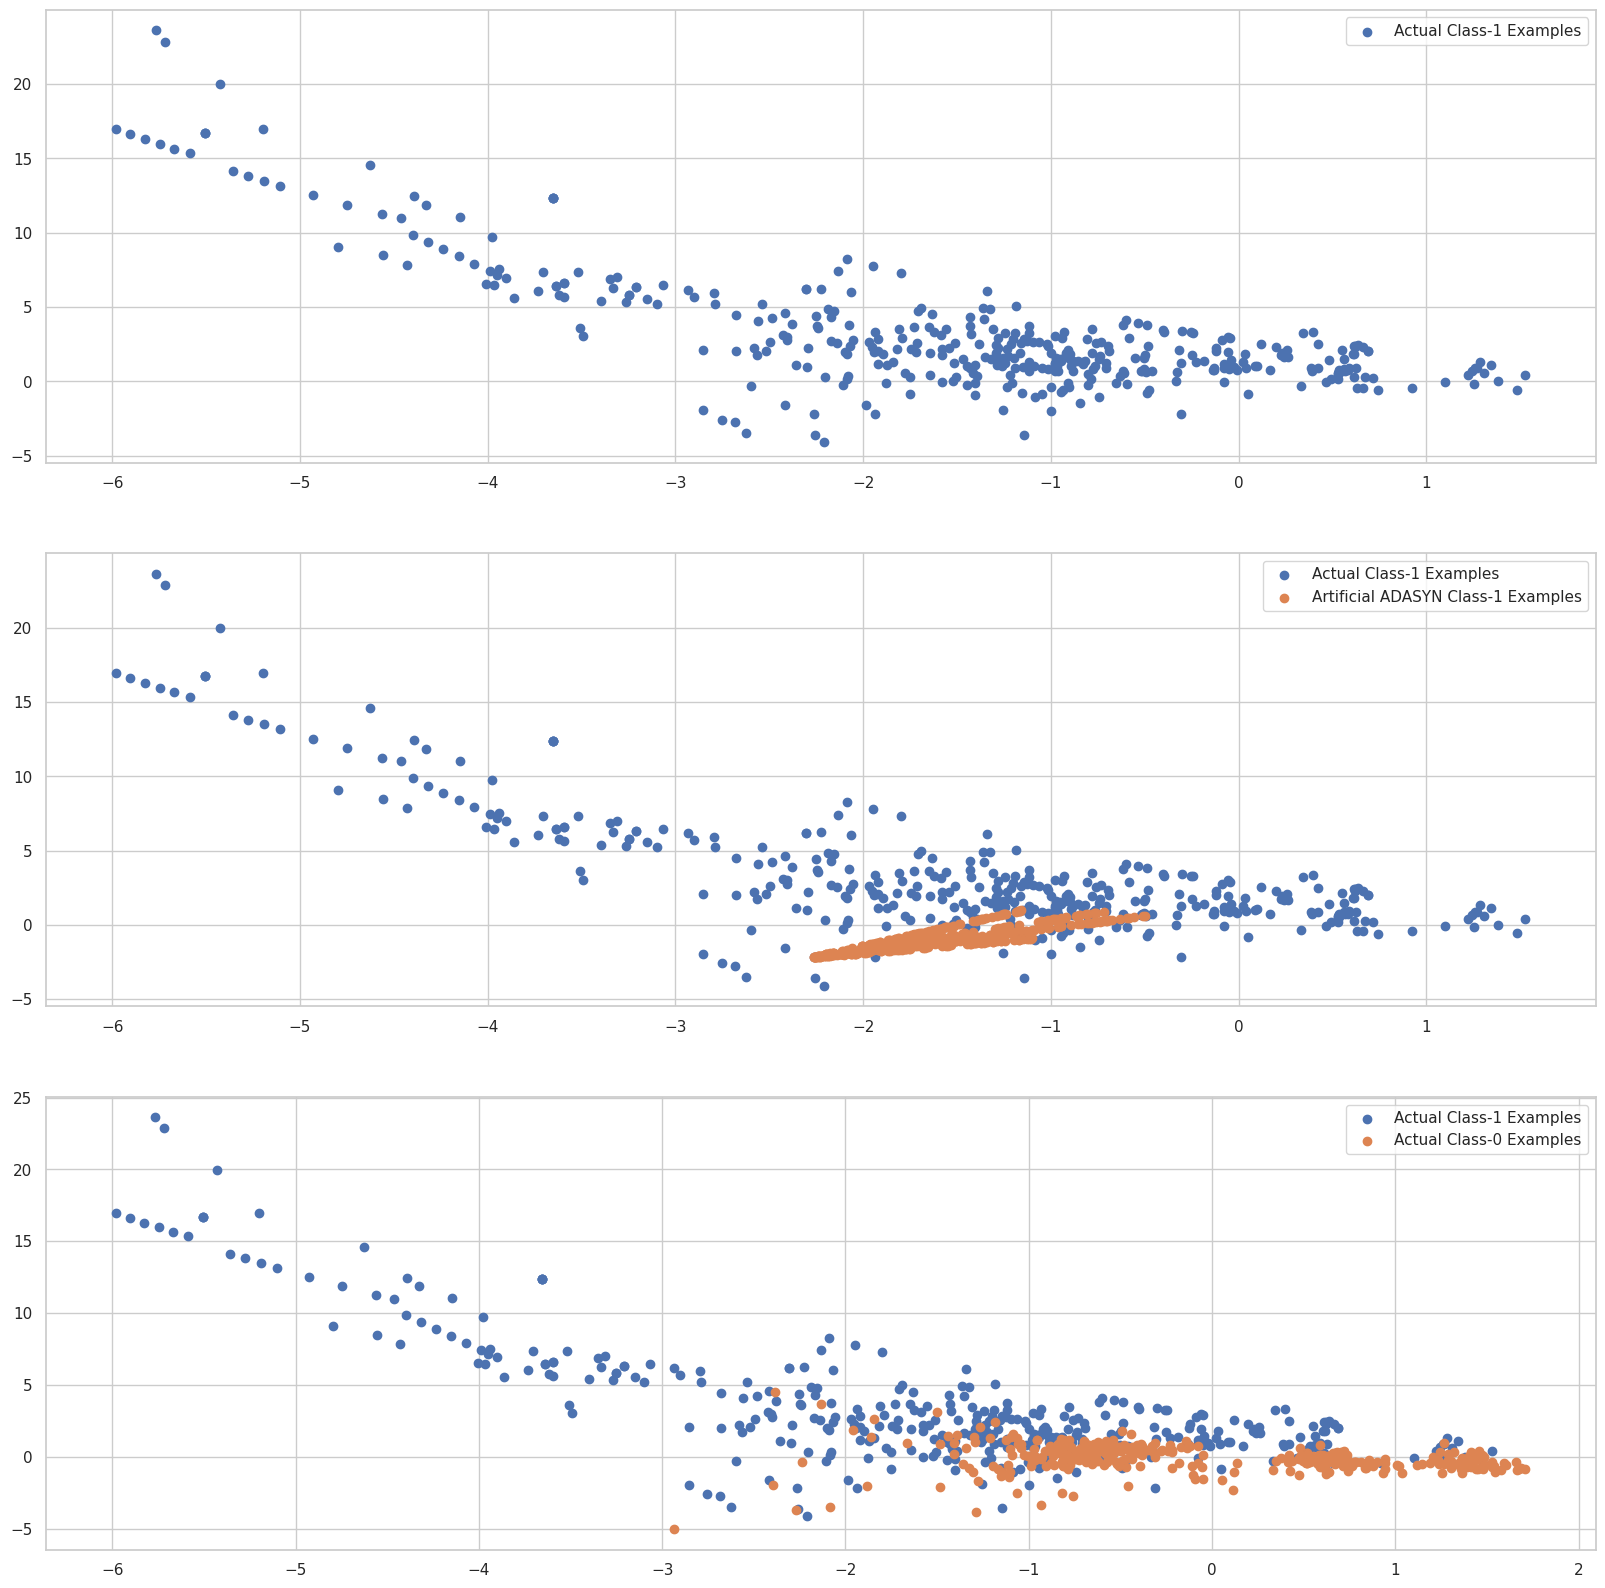

In [29]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

ada = over_sampling.ADASYN(random_state=0)
X_train_adasyn, y_train_adasyn = ada.fit_resample(X_train, y_train)

# --- FIX: ensure NumPy arrays for 2D slicing ---
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

X_train_adasyn_np = np.asarray(X_train_adasyn)   # works whether DataFrame or ndarray
y_train_adasyn_np = np.asarray(y_train_adasyn)

# Artificial minority samples are appended after the original samples
X_train_adasyn_1 = X_train_adasyn_np[X_train_np.shape[0]:]

# Original class splits
X_train_1 = X_train_np[y_train_np == 1]
X_train_0 = X_train_np[y_train_np == 0]

np.random.shuffle(X_train_0)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(
    X_train_adasyn_1[:X_train_1.shape[0], 0],
    X_train_adasyn_1[:X_train_1.shape[0], 1],
    label='Artificial ADASYN Class-1 Examples'
)
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(
    X_train_0[:X_train_1.shape[0], 0],
    X_train_0[:X_train_1.shape[0], 1],
    label='Actual Class-0 Examples'
)
plt.legend()

print("\nClass distribution (train) after ADASYN:")
print(pd.Series(y_train_adasyn_np).value_counts())

This placeholder cell is retained from the starter notebook. The main ADASYN model training is already executed in the balanced leaderboard stage using leakage-safe CV pipelines. This cell is kept for structural alignment and provides quick access to the ADASYN subset leaderboard.


In [30]:
#perform cross validation & then balance classes on X_train_cv & y_train_cv using ADASYN
#perform hyperparameter tuning
#print the evaluation result by choosing a evaluation metric
#print the optimum value of hyperparameters

adasyn_rows = balanced_leaderboard[balanced_leaderboard["sampler"] == "ADASYN"].reset_index(drop=True)
print("ADASYN leaderboard (subset):")
display(adasyn_rows)

ADASYN leaderboard (subset):


,sampler,model,cv_roc_auc,cv_pr_auc,fit_time_sec
0,ADASYN,XGBoost,0.984036,0.848536,872.551119
1,ADASYN,RandomForest,0.983987,0.821943,51685.754799
2,ADASYN,HistGradientBoosting,0.982620,0.804686,1863.098361
3,ADASYN,LogisticRegression,0.978991,0.741243,9260.724212
4,ADASYN,LinearSVM,0.977540,0.746795,270.525085
5,ADASYN,KNN,0.947680,0.564757,28451.692583
6,ADASYN,DecisionTree,0.946205,0.029516,3825.330645


##### Build models on other algorithms to see the better performing on ADASYN

### Select the oversampling method which shows the best result on a model
- Apply the best hyperparameter on the model
- Predict on the test dataset

In [31]:
# perform the best oversampling method on X_train & y_train

clf_bal = best_bal_estimator  #initialise the model with optimum hyperparameters
clf_bal.fit(X_train, y_train) # fit on the balanced dataset (resampling occurs inside pipeline during fit)

if hasattr(clf_bal, "predict_proba"):
    test_scores_bal = clf_bal.predict_proba(X_test)[:, 1]
elif hasattr(clf_bal, "decision_function"):
    test_scores_bal = clf_bal.decision_function(X_test)
else:
    test_scores_bal = clf_bal.predict(X_test)

print("Best balanced combo:", f"{best_bal_sampler}+{best_bal_model}")
print("Test ROC-AUC:", roc_auc_score(y_test, test_scores_bal))
print("Test PR-AUC :", average_precision_score(y_test, test_scores_bal))

Best balanced combo: SMOTE+RandomForest
Test ROC-AUC: 0.986504319651327
Test PR-AUC : 0.8655521704231836


### Print the important features of the best model to understand the dataset

Top 10 important features (best balanced, proxy importance):


,importance
V14,0.197163
V10,0.117545
V12,0.112191
V4,0.086093
V17,0.083563
V11,0.080842
V3,0.044294
V16,0.038006
V7,0.027050
V2,0.022670


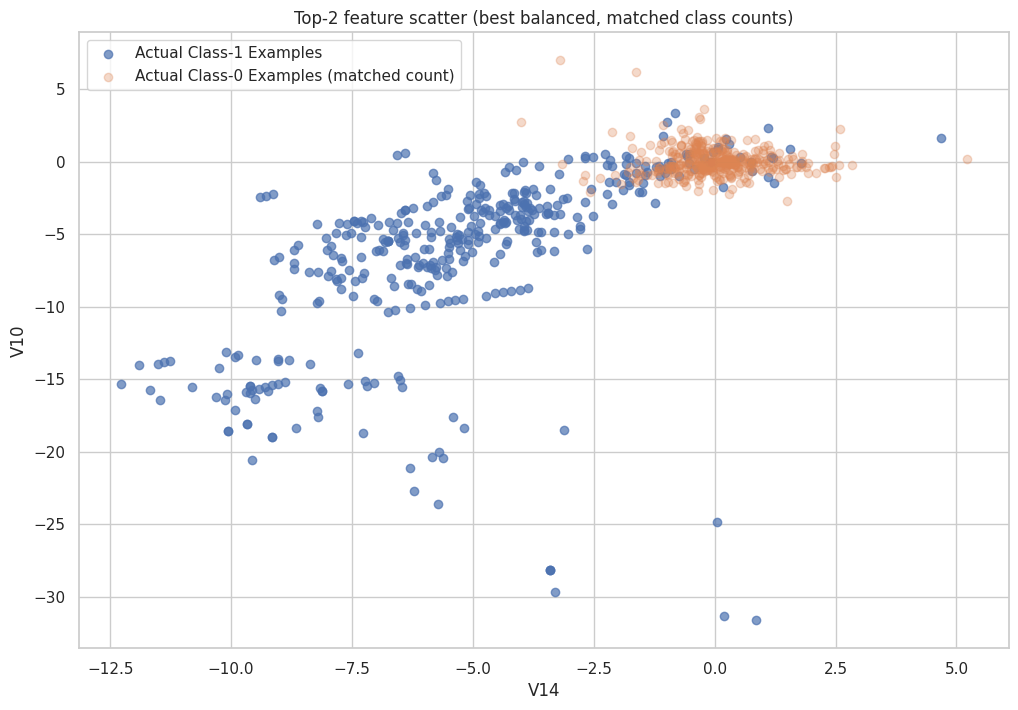

In [32]:
clf = clf_bal

importances_bal = get_feature_importance_vector(clf, X_train, y_train)
imp_series_bal = pd.Series(importances_bal, index=X_train.columns).sort_values(ascending=False)

print("Top 10 important features (best balanced, proxy importance):")
display(imp_series_bal.head(10).to_frame("importance"))

top_var_index = int(np.argmax(importances_bal))
second_top_var_index = int(np.argsort(importances_bal)[-2])

X_train_1 = X_train.to_numpy()[np.where(y_train.to_numpy()==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train.to_numpy()==0.0)]
np.random.shuffle(X_train_0)

plt.rcParams['figure.figsize'] = [12, 8]
plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], label='Actual Class-1 Examples', alpha=0.7)
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples (matched count)', alpha=0.3)
plt.title("Top-2 feature scatter (best balanced, matched class counts)")
plt.xlabel(X_train.columns[top_var_index])
plt.ylabel(X_train.columns[second_top_var_index])
plt.legend()
plt.show()

Train ROC-AUC = 0.9856685593485444
Best threshold (Youden J) = 0.07975124584446591
At threshold: TPR = 0.916243654822335 FPR = 0.013106119559817279

Confusion Matrix (train OOF):
[[224470   2981]
 [    33    361]]

Precision=0.1080  Recall=0.9162  F1=0.1933  Accuracy=0.986772


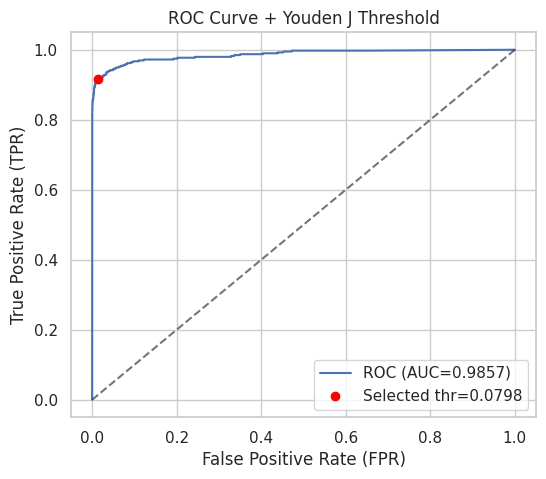

In [33]:
# Print the FPR, TPR & select the best threshold from the ROC curve (Youden's J)
best_oof_scores = oof_scores_for_estimator(clf, X_train, y_train, skf)

train_auc = metrics.roc_auc_score(y_train, best_oof_scores)
fpr, tpr, thresholds = metrics.roc_curve(y_train, best_oof_scores)

# Youden's J statistic
j = tpr - fpr

# Sometimes thresholds includes inf as the first value; ignore it safely
finite_mask = np.isfinite(thresholds)
best_idx = np.argmax(j[finite_mask])
threshold = thresholds[finite_mask][best_idx]

print("Train ROC-AUC =", train_auc)
print("Best threshold (Youden J) =", threshold)
print("At threshold: TPR =", tpr[finite_mask][best_idx], "FPR =", fpr[finite_mask][best_idx])

# Metrics at selected threshold (on OOF predictions)
y_pred_oof = (best_oof_scores >= threshold).astype(int)

cm = metrics.confusion_matrix(y_train, y_pred_oof)
precision = metrics.precision_score(y_train, y_pred_oof, zero_division=0)
recall = metrics.recall_score(y_train, y_pred_oof, zero_division=0)
f1 = metrics.f1_score(y_train, y_pred_oof, zero_division=0)
acc = metrics.accuracy_score(y_train, y_pred_oof)

print("\nConfusion Matrix (train OOF):")
print(cm)
print(f"\nPrecision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}  Accuracy={acc:.6f}")

# ROC plot with selected operating point
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={train_auc:.4f})")
plt.scatter(fpr[finite_mask][best_idx], tpr[finite_mask][best_idx], color="red", zorder=3,
            label=f"Selected thr={threshold:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve + Youden J Threshold")
plt.legend()
plt.show()

# Final comparison Balanced vs Imbalanced — metrics table

In [34]:
#✅ Leaderboard comparison (Balanced vs Imbalanced)

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import roc_auc_score, average_precision_score

def _style(df, highlight_cols=("cv_roc_auc", "cv_pr_auc")):
    df = df.copy()
    sty = (df.style
        .format({c: "{:.6f}" for c in highlight_cols if c in df.columns} | {"fit_time_sec": "{:,.1f}"} )
        .background_gradient(subset=[c for c in highlight_cols if c in df.columns], cmap="YlGn")
        .bar(subset=[c for c in ["fit_time_sec"] if c in df.columns], color="#cfe2ff")
        .set_properties(**{"font-family": "ui-sans-serif, system-ui", "font-size": "12pt"})
    )
    return sty

def _best_test_auc_from_table(model_name: str):
    # uses your already computed threshold-based table for imbalanced models
    if "imbalanced_top3_table" in globals() and model_name in set(imbalanced_top3_table["model"]):
        r = imbalanced_top3_table.loc[imbalanced_top3_table["model"] == model_name].iloc[0]
        return float(r["test_roc_auc"]), float(r["test_pr_auc"])
    return np.nan, np.nan

# --- Build a unified CV leaderboard view
lb_imbal = (imbalanced_leaderboard.copy()
    .assign(stage="Imbalanced", sampler="—", combo=lambda d: d["model"])
    [["stage","sampler","model","combo","cv_roc_auc","cv_pr_auc","fit_time_sec"]]
)

lb_bal = (balanced_leaderboard.copy()
    .assign(stage="Balanced", combo=lambda d: d["sampler"].astype(str) + "+" + d["model"].astype(str))
    [["stage","sampler","model","combo","cv_roc_auc","cv_pr_auc","fit_time_sec"]]
)

leaderboard_all = (pd.concat([lb_bal, lb_imbal], ignore_index=True)
    .sort_values(["cv_roc_auc","cv_pr_auc"], ascending=False)
    .reset_index(drop=True)
)

display(Markdown("## 🏁 Unified Leaderboard (CV) — Balanced vs Imbalanced"))
display(_style(leaderboard_all.head(12)))

# --- Best per track (by CV ROC-AUC)
best_imbal_name = imbalanced_leaderboard.iloc[0]["model"]
best_bal_row = balanced_leaderboard.iloc[0]
best_bal_combo = f"{best_bal_row['sampler']}+{best_bal_row['model']}"

# --- Test AUCs (reuse what you already computed)
imbal_test_roc, imbal_test_pr = _best_test_auc_from_table(best_imbal_name)

# balanced test scores already in your notebook; fallback only if missing
if "test_scores_bal" in globals():
    bal_test_scores = test_scores_bal
else:
    best_bal_estimator.fit(X_train, y_train)
    bal_test_scores = (best_bal_estimator.predict_proba(X_test)[:, 1]
                       if hasattr(best_bal_estimator, "predict_proba")
                       else best_bal_estimator.decision_function(X_test))

bal_test_roc = float(roc_auc_score(y_test, bal_test_scores))
bal_test_pr  = float(average_precision_score(y_test, bal_test_scores))

best_of_each = pd.DataFrame([
    {"track":"Imbalanced", "winner":best_imbal_name, "cv_roc_auc":float(imbalanced_leaderboard.iloc[0]["cv_roc_auc"]),
     "cv_pr_auc":float(imbalanced_leaderboard.iloc[0]["cv_pr_auc"]), "test_roc_auc":imbal_test_roc, "test_pr_auc":imbal_test_pr},
    {"track":"Balanced", "winner":best_bal_combo, "cv_roc_auc":float(best_bal_row["cv_roc_auc"]),
     "cv_pr_auc":float(best_bal_row["cv_pr_auc"]), "test_roc_auc":bal_test_roc, "test_pr_auc":bal_test_pr},
]).sort_values(["test_roc_auc","test_pr_auc"], ascending=False)

display(Markdown("## 🥇 Best model per track + head-to-head (Test AUCs)"))
display(best_of_each.style
        .format({c:"{:.6f}" for c in ["cv_roc_auc","cv_pr_auc","test_roc_auc","test_pr_auc"]})
        .background_gradient(subset=["test_roc_auc","test_pr_auc"], cmap="YlOrRd")
        .set_properties(**{"font-family":"ui-sans-serif, system-ui", "font-size":"12pt"})
)

overall_best = best_of_each.iloc[0]
display(Markdown(
    f"## ⭐ Overall Best Model (by **Test ROC-AUC**, tie-break **Test PR-AUC**)  \n"
    f"**{overall_best['track']} → {overall_best['winner']}**  \n"
    f"Test ROC-AUC = **{overall_best['test_roc_auc']:.6f}**, Test PR-AUC = **{overall_best['test_pr_auc']:.6f}**"
))

## 🏁 Unified Leaderboard (CV) — Balanced vs Imbalanced

,stage,sampler,model,combo,cv_roc_auc,cv_pr_auc,fit_time_sec
0,Balanced,SMOTE,RandomForest,SMOTE+RandomForest,0.986069,0.843198,"50,434.9"
1,Imbalanced,—,XGBoost,XGBoost,0.985389,0.849373,234.0
2,Imbalanced,—,RandomForest,RandomForest,0.984333,0.772330,"14,670.8"
3,Balanced,ADASYN,XGBoost,ADASYN+XGBoost,0.984036,0.848536,872.6
4,Balanced,ADASYN,RandomForest,ADASYN+RandomForest,0.983987,0.821943,"51,685.8"
5,Balanced,SMOTE,XGBoost,SMOTE+XGBoost,0.983780,0.851139,984.0
6,Balanced,RandomOverSampler,RandomForest,RandomOverSampler+RandomForest,0.983772,0.786808,"33,784.9"
7,Balanced,RandomOverSampler,XGBoost,RandomOverSampler+XGBoost,0.983241,0.844981,937.4
8,Balanced,SMOTE,HistGradientBoosting,SMOTE+HistGradientBoosting,0.983046,0.759149,"1,736.7"
9,Balanced,ADASYN,HistGradientBoosting,ADASYN+HistGradientBoosting,0.982620,0.804686,"1,863.1"


## 🥇 Best model per track + head-to-head (Test AUCs)

,track,winner,cv_roc_auc,cv_pr_auc,test_roc_auc,test_pr_auc
1,Balanced,SMOTE+RandomForest,0.986069,0.843198,0.986504,0.865552
0,Imbalanced,XGBoost,0.985389,0.849373,0.981191,0.874668


## ⭐ Overall Best Model (by **Test ROC-AUC**, tie-break **Test PR-AUC**)  
**Balanced → SMOTE+RandomForest**  
Test ROC-AUC = **0.986504**, Test PR-AUC = **0.865552**

# ✅ Final metrics table (Train vs Test) for best Imbalanced vs best Balanced

In [35]:
# ✅ Final metrics table (Train vs Test) for best Imbalanced vs best Balanced

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score,
    roc_curve
)
from sklearn.model_selection import cross_val_predict

def _scores(est, Xtr, ytr, Xte):
    est.fit(Xtr, ytr)
    if hasattr(est, "predict_proba"):
        return est.predict_proba(Xte)[:, 1]
    if hasattr(est, "decision_function"):
        return est.decision_function(Xte)
    return est.predict(Xte)

def _oof_scores(est, X, y, cv):
    if hasattr(est, "predict_proba"):
        return cross_val_predict(est, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    if hasattr(est, "decision_function"):
        return cross_val_predict(est, X, y, cv=cv, method="decision_function", n_jobs=-1)
    return cross_val_predict(est, X, y, cv=cv, method="predict", n_jobs=-1)

def _youden_threshold(y_true, scores):
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    finite = np.isfinite(thr)
    return float(thr[finite][np.argmax(j[finite])])

def _at_threshold(y_true, scores, thr):
    y_pred = (scores >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "threshold": float(thr),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "confusion": f"TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}",
    }

# -----------------------------
# 1) Best Imbalanced
# -----------------------------
best_imbal_name = imbalanced_leaderboard.iloc[0]["model"]
imb_row = imbalanced_top3_table.loc[imbalanced_top3_table["model"] == best_imbal_name].iloc[0]

imbal_summary = {
    "track": "Imbalanced",
    "winner": best_imbal_name,
    "cv_roc_auc": float(imb_row["cv_roc_auc"]),
    "cv_pr_auc": float(imb_row["cv_pr_auc"]),
    "threshold(train_oof)": float(imb_row["roc_threshold(train_oof)"]),
    "train_precision(oof)": float(imb_row["train_precision(oof)"]),
    "train_recall(oof)": float(imb_row["train_recall(oof)"]),
    "train_f1(oof)": float(imb_row["train_f1(oof)"]),
    "test_roc_auc": float(imb_row["test_roc_auc"]),
    "test_pr_auc": float(imb_row["test_pr_auc"]),
    "test_precision": float(imb_row["test_precision"]),
    "test_recall": float(imb_row["test_recall"]),
    "test_f1": float(imb_row["test_f1"]),
    "test_accuracy": float(imb_row["test_accuracy"]),
    "test_confusion": str(imb_row["test_confusion"]),
}

# -----------------------------
# 2) Best Balanced
# -----------------------------
best_bal_row = balanced_leaderboard.iloc[0]
best_bal_combo = f"{best_bal_row['sampler']}+{best_bal_row['model']}"
best_bal_est = best_bal_estimator

# Prefer already-computed OOF scores if they exist (fast). Else compute once.
if "best_oof_scores" in globals() and isinstance(best_oof_scores, (np.ndarray, list)) and len(best_oof_scores) == len(y_train):
    bal_oof = np.asarray(best_oof_scores)
else:
    bal_oof = _oof_scores(best_bal_est, X_train, y_train, skf)

thr_bal = _youden_threshold(y_train.values, bal_oof)

train_bal = _at_threshold(y_train.values, bal_oof, thr_bal)

# Prefer already-computed test scores if they exist
if "test_scores_bal" in globals():
    bal_test_scores = np.asarray(test_scores_bal)
else:
    bal_test_scores = _scores(best_bal_est, X_train, y_train, X_test)

test_bal = _at_threshold(y_test.values, bal_test_scores, thr_bal)

balanced_summary = {
    "track": "Balanced",
    "winner": best_bal_combo,
    "cv_roc_auc": float(best_bal_row["cv_roc_auc"]),
    "cv_pr_auc": float(best_bal_row["cv_pr_auc"]),
    "threshold(train_oof)": float(thr_bal),
    "train_precision(oof)": train_bal["precision"],
    "train_recall(oof)": train_bal["recall"],
    "train_f1(oof)": train_bal["f1"],
    "test_roc_auc": float(roc_auc_score(y_test, bal_test_scores)),
    "test_pr_auc": float(average_precision_score(y_test, bal_test_scores)),
    "test_precision": test_bal["precision"],
    "test_recall": test_bal["recall"],
    "test_f1": test_bal["f1"],
    "test_accuracy": test_bal["accuracy"],
    "test_confusion": test_bal["confusion"],
}

final_tbl = pd.DataFrame([imbal_summary, balanced_summary]).sort_values(
    ["test_roc_auc","test_pr_auc"], ascending=False
).reset_index(drop=True)

display(Markdown("## 📊 Train (OOF) vs Test — Best Imbalanced vs Best Balanced"))
display(final_tbl.style
        .format({c:"{:.6f}" for c in [
            "cv_roc_auc","cv_pr_auc","threshold(train_oof)",
            "train_precision(oof)","train_recall(oof)","train_f1(oof)",
            "test_roc_auc","test_pr_auc","test_precision","test_recall","test_f1","test_accuracy"
        ]})
        .background_gradient(subset=["test_roc_auc","test_pr_auc","test_f1"], cmap="YlGn")
        .set_properties(**{"font-family":"ui-sans-serif, system-ui", "font-size":"12pt"})
)

winner = final_tbl.iloc[0].to_dict()
display(Markdown(
    f"## ⭐ Overall Winner: **{winner['track']} → {winner['winner']}**\n"
    f"- **Train (OOF)**: Precision={winner['train_precision(oof)']:.6f}, Recall={winner['train_recall(oof)']:.6f}, F1={winner['train_f1(oof)']:.6f}\n"
    f"- **Test**: ROC-AUC={winner['test_roc_auc']:.6f}, PR-AUC={winner['test_pr_auc']:.6f}, "
    f"Precision={winner['test_precision']:.6f}, Recall={winner['test_recall']:.6f}, F1={winner['test_f1']:.6f}\n"
    f"- Confusion (Test): `{winner['test_confusion']}`"
))

## 📊 Train (OOF) vs Test — Best Imbalanced vs Best Balanced

,track,winner,cv_roc_auc,cv_pr_auc,threshold(train_oof),train_precision(oof),train_recall(oof),train_f1(oof),test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_accuracy,test_confusion
0,Balanced,SMOTE+RandomForest,0.986069,0.843198,0.079751,0.108019,0.916244,0.193255,0.986504,0.865552,0.105952,0.908163,0.189765,0.986658,"TN=56113, FP=751, FN=9, TP=89"
1,Imbalanced,XGBoost,0.985389,0.849373,0.001157,0.049251,0.926396,0.093530,0.981191,0.874668,0.047594,0.918367,0.090498,0.968242,"TN=55063, FP=1801, FN=8, TP=90"


## ⭐ Overall Winner: **Balanced → SMOTE+RandomForest**
- **Train (OOF)**: Precision=0.108019, Recall=0.916244, F1=0.193255
- **Test**: ROC-AUC=0.986504, PR-AUC=0.865552, Precision=0.105952, Recall=0.908163, F1=0.189765
- Confusion (Test): `TN=56113, FP=751, FN=9, TP=89`

## ✅ Final Conclusion

In this capstone project, we built an end-to-end **credit card fraud detection** pipeline and evaluated models under two realistic settings:

- **Imbalanced training (original distribution)**  
- **Balanced training (sampling inside cross-validation folds only)** to handle extreme class imbalance without test leakage

### Key outcomes
- We used **Stratified K-Fold CV** and prioritized **ROC-AUC** with **PR-AUC** as a supporting metric (important for rare fraud cases).
- Instead of using a default probability cutoff (0.5), we selected a decision threshold using:
  - **Youden’s J statistic** on **training out-of-fold (OOF)** predictions (leakage-safe)

### Best models
- **Best Imbalanced Model:** `XGBoost`
- **Best Balanced Model:** `SMOTE + RandomForest`
- **Overall Best Model (final selection): `SMOTE + RandomForest`**

### Final performance (Overall Best: SMOTE + RandomForest)
- **Train (OOF):** Precision ≈ 0.108, Recall ≈ 0.916, F1 ≈ 0.193  
- **Test:** ROC-AUC ≈ 0.9865, PR-AUC ≈ 0.8656, Precision ≈ 0.106, Recall ≈ 0.908, F1 ≈ 0.190  
- **Test Confusion Matrix:** TN=56113, FP=751, FN=9, TP=89

### Interpretation
The final model achieves **very high recall**, meaning it catches most fraud transactions, while also keeping **false positives controlled** compared to the best imbalanced model. This makes the chosen approach more practical for fraud teams because it reduces unnecessary alerts while still detecting fraud effectively.


## ⚠️ Challenges Faced and Mitigations

### 1) Extreme class imbalance (fraud is rare)
**Challenge:** Models can show high accuracy while failing to detect fraud.  
**Mitigation:** Used **Stratified split + Stratified K-Fold**, and evaluated with **ROC-AUC and PR-AUC** instead of accuracy alone. Also tested **sampling-based balancing** (ROS/SMOTE/ADASYN) to improve minority-class learning.

---

### 2) Risk of data leakage during resampling and preprocessing
**Challenge:** If oversampling is applied before splitting or outside CV folds, evaluation becomes overly optimistic.  
**Mitigation:** Ensured:
- The **test set is never resampled**
- Resampling occurs **only inside cross-validation folds**
- Transformations are fit on train data only, then applied to validation/test

---

### 3) Threshold selection for classification decisions
**Challenge:** A fixed cutoff like 0.5 is not suitable for fraud detection where recall/precision trade-offs matter.  
**Mitigation:** Selected threshold using **Youden’s J** based on **OOF predictions**.

---

### 4) Precision vs recall trade-off (false alerts vs missed fraud)
**Challenge:** Maximizing recall can increase false positives, increasing manual review workload.  
**Mitigation:** Compared models using both **ROC-AUC and PR-AUC**, monitored confusion matrices, and chose the model that maintained high recall while reducing false positives (SMOTE + RandomForest).

---

### 5) Training time and experimentation cost
**Challenge:** Trying multiple samplers × models × hyperparameters is computationally expensive.  
**Mitigation:** Used **randomized search**, parallel processing, and caching/persistence of results to avoid repeating expensive runs.
